# HR Employee Attrition Analysis

**Dataset:** IBM synthetic HR dataset — 1,470 employees, 35 attributes.  
**Goal:** Identify factors *associated* with employee turnover, compute retention KPIs, and produce data-driven recommendations for HR stakeholders.  

> **Important framing:** The dataset is entirely synthetic. All findings are exercises in analytical method, not statements about a real company. Because the data is cross-sectional (a single snapshot in time), we can describe *associations* between variables but **cannot claim causation**. Every recommendation is a hypothesis worth testing, not a proven fact.

---

## Table of Contents
1. [Data Extraction — SQL Query](#sql)
2. [Load & Inspect Data](#load)
3. [Missing Values](#missing)
4. [Drop Zero-Variance Columns](#zero-variance)
5. [Create Numeric Attrition Flag](#flag)
6. [Summary Statistics & Distributions](#eda)
7. [Correlation Heatmap](#heatmap)
8. [KPI 1 — Attrition Rate](#kpi1)
9. [KPI 2 — Compensation & Retention](#kpi2)
10. [KPI 3 — Work-Life Balance & Satisfaction](#kpi3)
11. [KPI 4 — Career Progression & Tenure](#kpi4)
12. [KPI 5 — Performance & Training](#kpi5)
13. [KPI 6 — Commute Distance](#kpi6)
14. [Retention Recommendations](#recs)
15. [Executive Summary for HR](#summary)

<a id='sql'></a>
## 1. Data Extraction — SQL Query

The raw data lives in a MySQL database (`hrdb`) across two tables:
- **`table1`** — demographics and department fields  
- **`table2`** — job, compensation, and satisfaction fields  

They are joined on `EmployeeNumber`. The join was validated in MySQL Workbench: **1,470 rows, 0 unmatched keys, 0 duplicate keys.** The result was exported to `HR_data.csv` which we load below.

Per course requirements, Python does *not* connect directly to MySQL — extraction is done in MySQL Workbench, and the CSV is the handoff point.

In [1]:
sql_query = """
USE hrdb;
SELECT t1.*,
       t2.EnvironmentSatisfaction, t2.Gender, t2.HourlyRate, t2.JobInvolvement,
       t2.JobLevel, t2.JobRole, t2.JobSatisfaction, t2.MaritalStatus,
       t2.MonthlyIncome, t2.MonthlyRate, t2.NumCompaniesWorked, t2.Over18,
       t2.OverTime, t2.PercentSalaryHike, t2.PerformanceRating,
       t2.RelationshipSatisfaction, t2.StandardHours, t2.StockOptionLevel,
       t2.TotalWorkingYears, t2.TrainingTimesLastYear, t2.WorkLifeBalance,
       t2.YearsAtCompany, t2.YearsInCurrentRole, t2.YearsSinceLastPromotion,
       t2.YearsWithCurrManager
FROM table1 t1
INNER JOIN table2 t2 ON t1.EmployeeNumber = t2.EmployeeNumber;
"""
# Result: 1,470 rows ֳ— 35 columns (single EmployeeNumber column after join).
# Exported from MySQL Workbench as HR_data.csv
print("SQL query documented above — extraction performed in MySQL Workbench.")

SQL query documented above — extraction performed in MySQL Workbench.


<a id='load'></a>
## 2. Load & Inspect the Data

We start by importing our standard data-science libraries and loading the CSV.  
**Why this matters:** Before any analysis, we need to verify the data arrived intact — correct shape, sensible column names, and expected data types. This is the foundation everything else builds on.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('HR_data.csv')

print(f"Shape: {df.shape[0]:,} rows ֳ— {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")

Shape: 1,470 rows ֳ— 35 columns

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [3]:
# Data types tell us which columns are numeric vs. categorical.
# Some numeric columns (like Education or JobSatisfaction) use numbers as
# ordered codes (1–4 scale), not raw quantities — we'll handle that in context.
print("Data types:")
print(df.dtypes.to_string())

Data types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
Tr

In [4]:
# First five rows give us a concrete feel for the data.
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<a id='missing'></a>
## 3. Missing Values

**Why we check:** Missing data can silently bias results — an imputation choice (e.g., filling with the mean) changes the distribution and can make patterns appear stronger or weaker than they really are.  

In this dataset, missing values are expected to be absent, but we always verify rather than assume.

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None — all 35 columns are complete.")
print(f"\nTotal cells: {df.size:,} | Missing: {df.isnull().sum().sum()}")

Missing values per column:
None — all 35 columns are complete.

Total cells: 51,450 | Missing: 0


**Finding:** There are **no missing values** anywhere in the dataset. No imputation was needed. This is expected for a synthetic dataset generated to be analysis-ready.

<a id='zero-variance'></a>
## 4. Drop Zero-Variance (Constant) Columns

**Why this matters:** A column that has the same value for every single employee carries *zero information* about differences between employees — including differences in attrition. Keeping it would clutter visualisations, confuse correlations, and waste compute.  

Three columns meet this criterion:
| Column | Constant Value | Meaning |
|---|---|---|
| `EmployeeCount` | 1 | Always 1 (redundant headcount counter) |
| `StandardHours` | 80 | Everyone is on the same 80-hour standard |
| `Over18` | "Y" | All employees are over 18 |

None of these can explain *why* some employees leave and others stay.

In [6]:
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18']

# Verify they are truly constant before dropping
for col in cols_to_drop:
    unique_vals = df[col].unique()
    print(f"{col}: unique values = {unique_vals}")

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nDataset shape after dropping: {df.shape[0]:,} rows ֳ— {df.shape[1]} columns")

EmployeeCount: unique values = [1]
StandardHours: unique values = [80]
Over18: unique values = <ArrowStringArray>
['Y']
Length: 1, dtype: str

Dataset shape after dropping: 1,470 rows ֳ— 32 columns


<a id='flag'></a>
## 5. Create Numeric Attrition Flag

The `Attrition` column stores text values (`"Yes"` / `"No"`). For computing rates, correlations, and group means we need a **numeric version** — `1` for left, `0` for stayed.  

**Why 1/0 (not some other encoding)?** It lets us compute the attrition rate directly as a column mean: `Attrition_Flag.mean()` = proportion of leavers. It also makes correlation with other numeric columns straightforward.

In [7]:
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)

counts = df['Attrition_Flag'].value_counts()
rate = df['Attrition_Flag'].mean()

print(f"Stayed  (0): {counts[0]:,} employees")
print(f"Left    (1): {counts[1]:,} employees")
print(f"Overall attrition rate: {rate:.1%}")

Stayed  (0): 1,233 employees
Left    (1): 237 employees
Overall attrition rate: 16.1%


<a id='eda'></a>
## 6. Summary Statistics & Distributions

Before diving into specific KPIs, we look at the overall shape of the data — range, centre, and spread of the key variables. This helps us spot outliers and get a sense of what's typical before we start slicing by attrition.

We focus on the variables most relevant to retention: age, income, distance, tenure, and the four satisfaction scales.

In [8]:
key_numeric = [
    'Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'JobSatisfaction', 'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance'
]

df[key_numeric].describe().round(2)

,Age,MonthlyIncome,DistanceFromHome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,6502.93,9.19,11.28,7.01,4.23,2.19,2.73,2.72,2.71,2.76
std,9.14,4707.96,8.11,7.78,6.13,3.62,3.22,1.10,1.09,1.08,0.71
min,18.00,1009.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,30.00,2911.00,2.00,6.00,3.00,2.00,0.00,2.00,2.00,2.00,2.00
50%,36.00,4919.00,7.00,10.00,5.00,3.00,1.00,3.00,3.00,3.00,3.00
75%,43.00,8379.00,14.00,15.00,9.00,7.00,3.00,4.00,4.00,4.00,3.00
max,60.00,19999.00,29.00,40.00,40.00,18.00,15.00,4.00,4.00,4.00,4.00


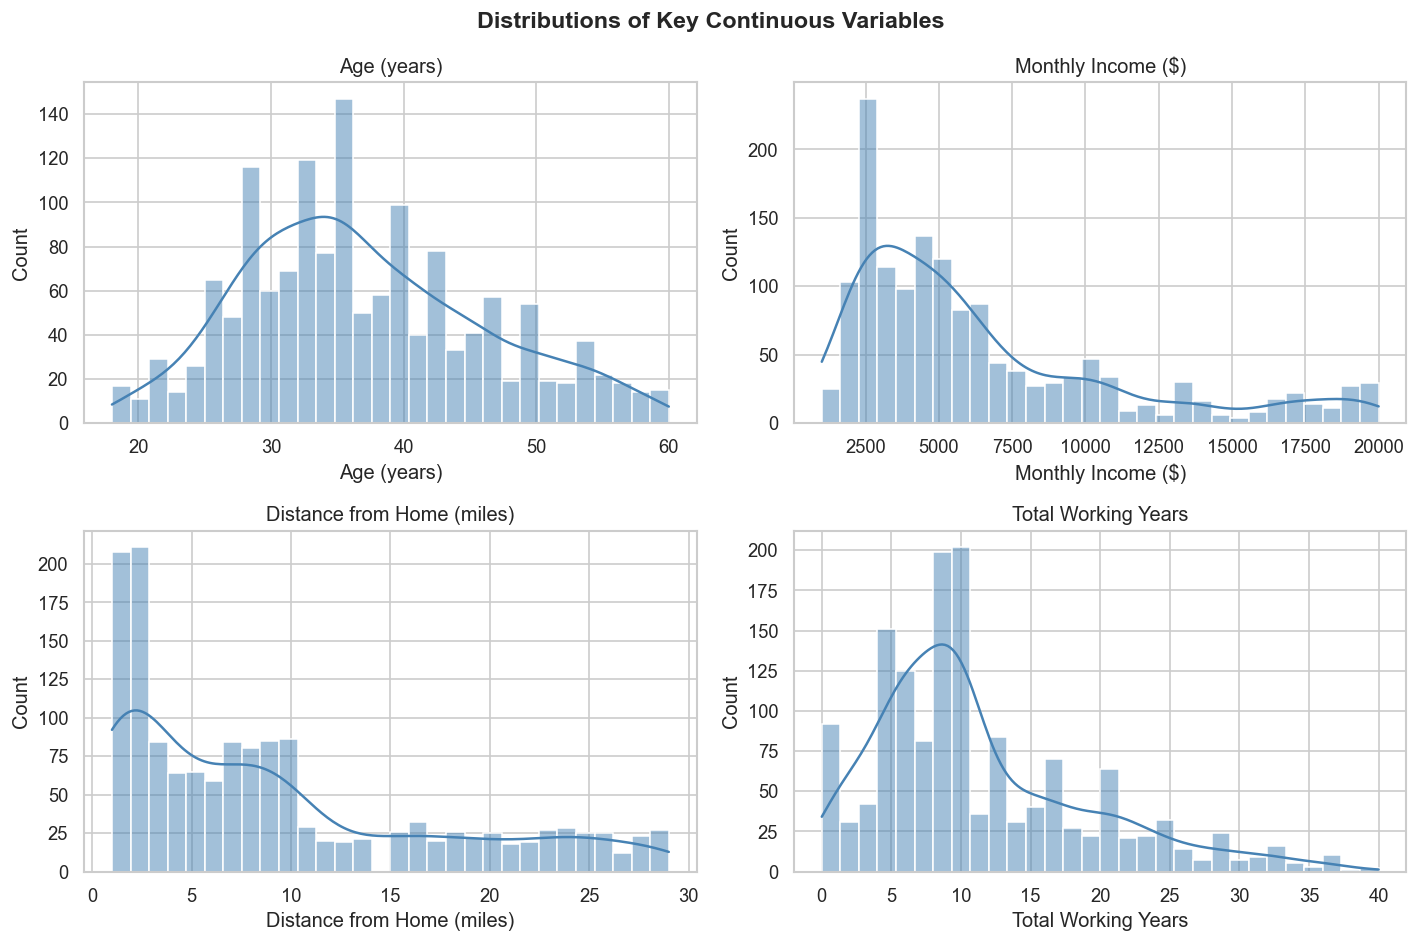

In [9]:
# Visualise distributions of the four main continuous variables.
# Histograms with KDE curves show both frequency and shape simultaneously.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distributions of Key Continuous Variables', fontsize=14, fontweight='bold')

plot_vars = [
    ('Age', 'Age (years)'),
    ('MonthlyIncome', 'Monthly Income ($)'),
    ('DistanceFromHome', 'Distance from Home (miles)'),
    ('TotalWorkingYears', 'Total Working Years'),
]

for ax, (col, label) in zip(axes.flatten(), plot_vars):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)

plt.tight_layout()
plt.show()

**Observations:**  
- **Age** is roughly bell-shaped, centred around 36–37.  
- **Monthly Income** is right-skewed — most employees earn in the lower-mid range, with a long tail of high earners. This is typical of corporate salary distributions.  
- **Distance from Home** is also right-skewed — the majority live close to the office, but a meaningful minority commute long distances.  
- **Total Working Years** is right-skewed as well — many junior employees, fewer long-tenured ones.

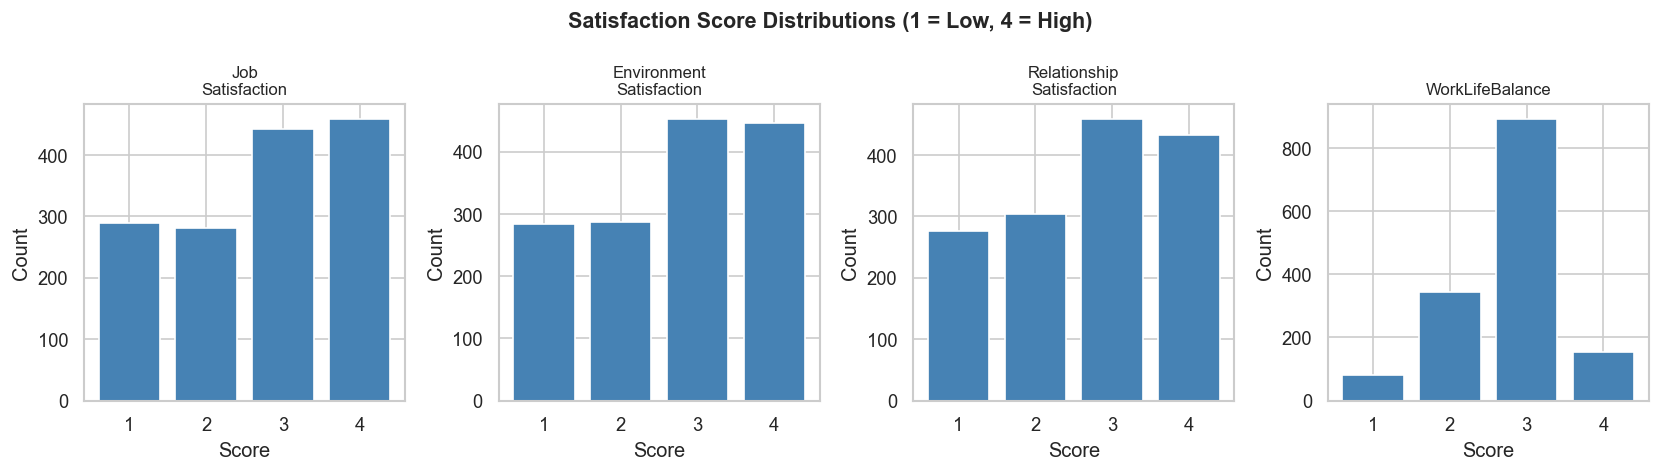

In [10]:
# Satisfaction scores (1–4 Likert scales). A bar chart is more appropriate
# than a histogram here because the values are discrete ordered categories.
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Satisfaction Score Distributions (1 = Low, 4 = High)', fontsize=13, fontweight='bold')

for ax, col in zip(axes, sat_cols):
    val_counts = df[col].value_counts().sort_index()
    ax.bar(val_counts.index, val_counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('Satisfaction', '\nSatisfaction'), fontsize=10)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.set_xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()

**Observation:** Satisfaction scores are relatively well distributed across the 1–4 range with a slight skew toward higher scores. This means low-satisfaction sub-groups are meaningfully represented — good for comparison.

<a id='heatmap'></a>
## 7. Correlation Heatmap

A correlation heatmap shows at a glance which numeric variables tend to move together. We include `Attrition_Flag` so we can immediately see which variables correlate positively (associated with leaving) or negatively (associated with staying).

**Important caveat:** Correlation ≠ causation. A strong correlation tells us two things move together — it does *not* tell us which one drives the other, or whether both are driven by a third hidden factor.

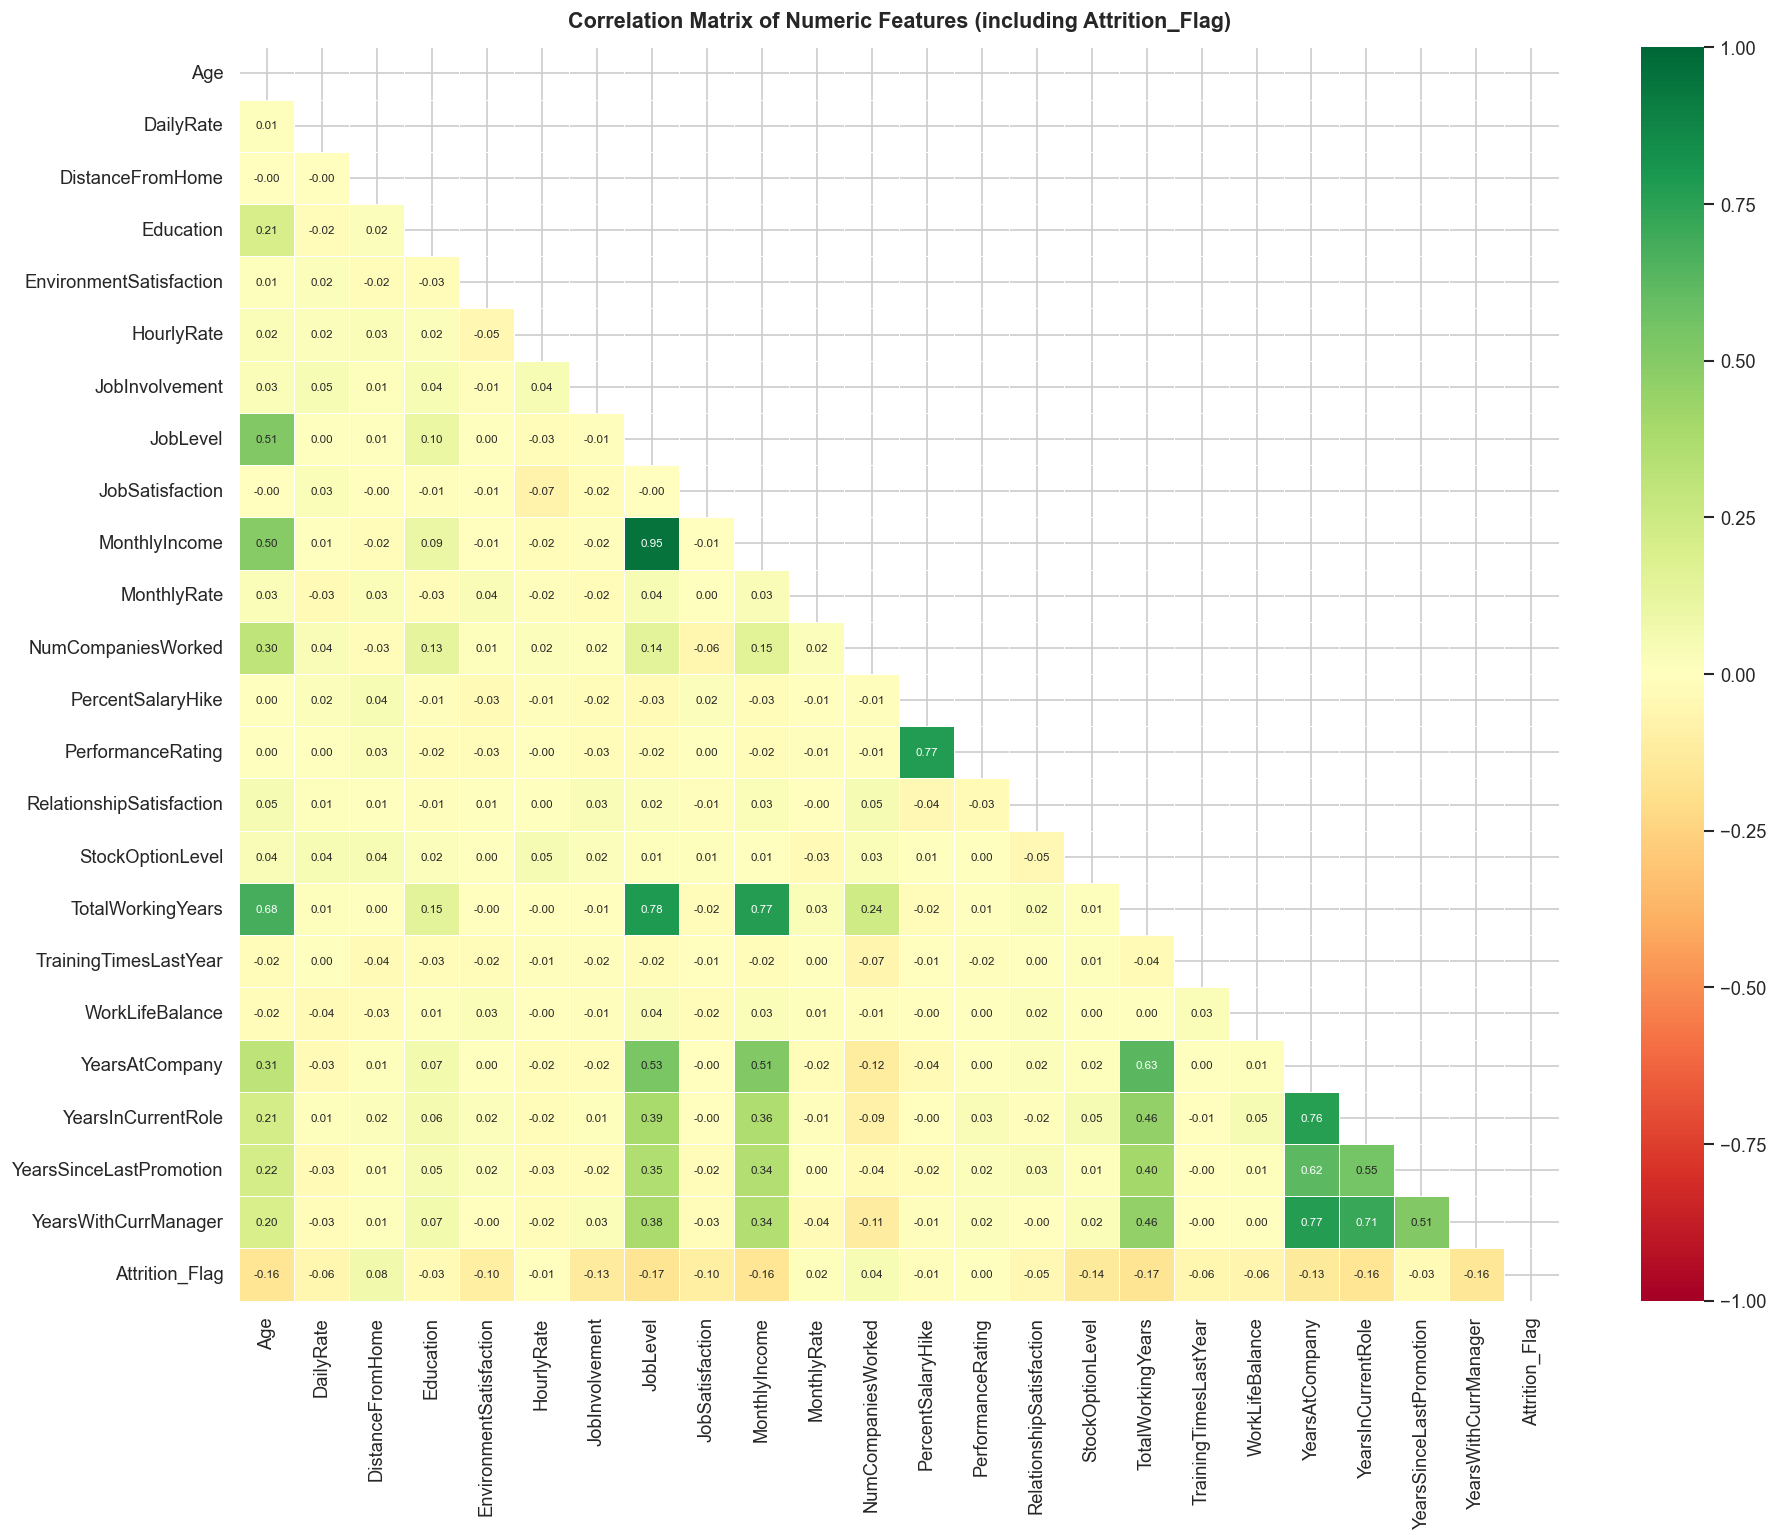

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove EmployeeNumber — it's an ID, not a meaningful quantity
if 'EmployeeNumber' in numeric_cols:
    numeric_cols.remove('EmployeeNumber')

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Correlation Matrix of Numeric Features (including Attrition_Flag)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

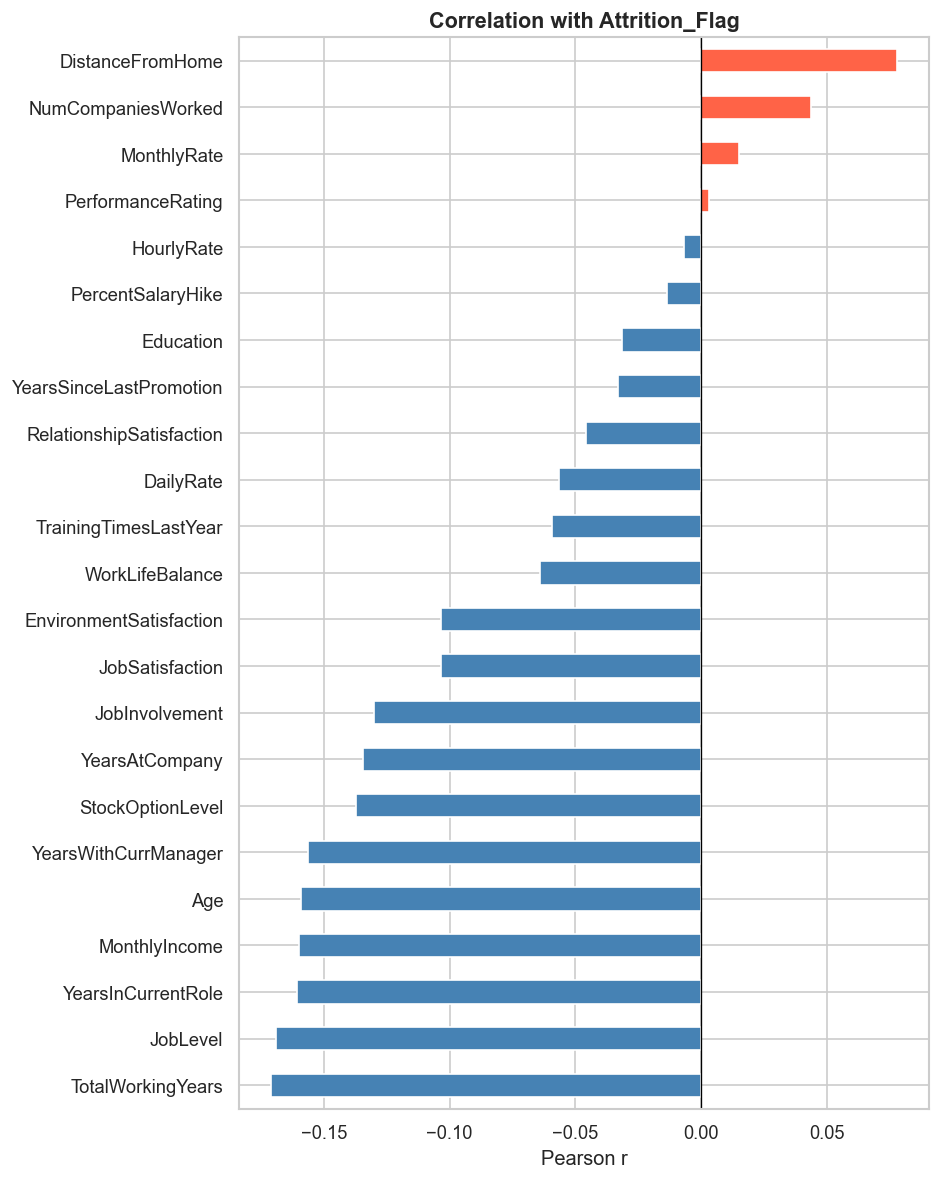

In [12]:
# Isolate the correlations with Attrition_Flag, sorted by strength
attrition_corr = corr_matrix['Attrition_Flag'].drop('Attrition_Flag').sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['tomato' if v > 0 else 'steelblue' for v in attrition_corr]
attrition_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with Attrition_Flag', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

**Key observations from the correlation with Attrition_Flag:**

> **Note:** the heatmap includes only **numeric** columns. `OverTime` is categorical (text), so it is *not* part of this correlation matrix — we analyse it separately by group in KPI 1, where it turns out to be one of the strongest signals.

| Direction | Top variables |
|---|---|
| **Positive** (more → higher attrition) | `DistanceFromHome` (r ≈ 0.08), `NumCompaniesWorked` (r ≈ 0.04) — both weak |
| **Negative** (more → lower attrition) | `TotalWorkingYears` (r ≈ −0.17), `JobLevel` (r ≈ −0.17), `YearsInCurrentRole`, `MonthlyIncome`, `Age` (all ≈ −0.16) |

Numeric correlations with attrition are modest at best; the categorical driver (OverTime) and the finer subgroup cuts below tell a stronger story.

---

# KPI Analysis

Each KPI section: (1) computes the metric, (2) visualises it, (3) interprets the finding, and (4) flags limitations.

<a id='kpi1'></a>
## KPI 1 — Attrition Rate: Overall, by Department, Job Role, and Tenure

**Why this KPI?** The headline rate tells us the scale of the problem. Breaking it down by department and role reveals *where* turnover is concentrated, which is the starting point for targeted interventions.

In [13]:
overall_rate = df['Attrition_Flag'].mean()
n_left = df['Attrition_Flag'].sum()
n_total = len(df)

print(f"Overall attrition rate: {overall_rate:.1%}  ({n_left} of {n_total} employees left)")

Overall attrition rate: 16.1%  (237 of 1470 employees left)


In [14]:
# --- By Department ---
dept_attr = (
    df.groupby('Department')['Attrition_Flag']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'Attrition Rate', 'sum': 'Leavers', 'count': 'Total'})
    .sort_values('Attrition Rate', ascending=False)
)
dept_attr['Attrition Rate %'] = (dept_attr['Attrition Rate'] * 100).round(1)
print("Attrition by Department:")
print(dept_attr[['Total', 'Leavers', 'Attrition Rate %']].to_string())

Attrition by Department:
                        Total  Leavers  Attrition Rate %
Department                                              
Sales                     446       92              20.6
Human Resources            63       12              19.0
Research & Development    961      133              13.8


In [15]:
# --- By Job Role ---
role_attr = (
    df.groupby('JobRole')['Attrition_Flag']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'Attrition Rate', 'sum': 'Leavers', 'count': 'Total'})
    .sort_values('Attrition Rate', ascending=False)
)
role_attr['Attrition Rate %'] = (role_attr['Attrition Rate'] * 100).round(1)
print("Attrition by Job Role:")
print(role_attr[['Total', 'Leavers', 'Attrition Rate %']].to_string())

Attrition by Job Role:
                           Total  Leavers  Attrition Rate %
JobRole                                                    
Sales Representative          83       33              39.8
Laboratory Technician        259       62              23.9
Human Resources               52       12              23.1
Sales Executive              326       57              17.5
Research Scientist           292       47              16.1
Manufacturing Director       145       10               6.9
Healthcare Representative    131        9               6.9
Manager                      102        5               4.9
Research Director             80        2               2.5


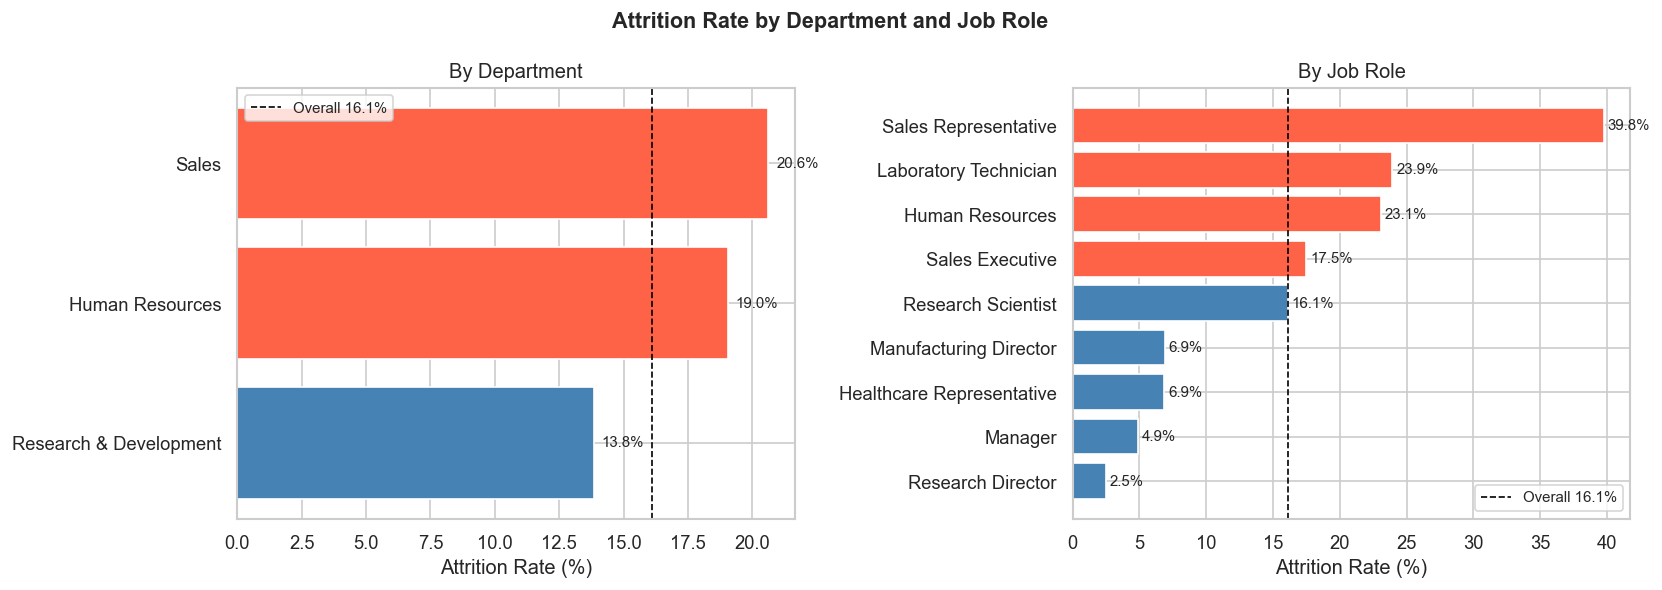

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attrition Rate by Department and Job Role', fontsize=13, fontweight='bold')

# Department
dept_plot = dept_attr['Attrition Rate'].sort_values(ascending=True)
bars = axes[0].barh(dept_plot.index, dept_plot.values * 100,
                    color=['tomato' if v > overall_rate else 'steelblue'
                           for v in dept_plot.values])
axes[0].axvline(overall_rate * 100, color='black', linestyle='--', linewidth=1, label=f'Overall {overall_rate:.1%}')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_title('By Department')
axes[0].legend(fontsize=9)
for bar in bars:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}%', va='center', fontsize=9)

# Job Role
role_plot = role_attr['Attrition Rate'].sort_values(ascending=True)
bars2 = axes[1].barh(role_plot.index, role_plot.values * 100,
                     color=['tomato' if v > overall_rate else 'steelblue'
                            for v in role_plot.values])
axes[1].axvline(overall_rate * 100, color='black', linestyle='--', linewidth=1, label=f'Overall {overall_rate:.1%}')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('By Job Role')
axes[1].legend(fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

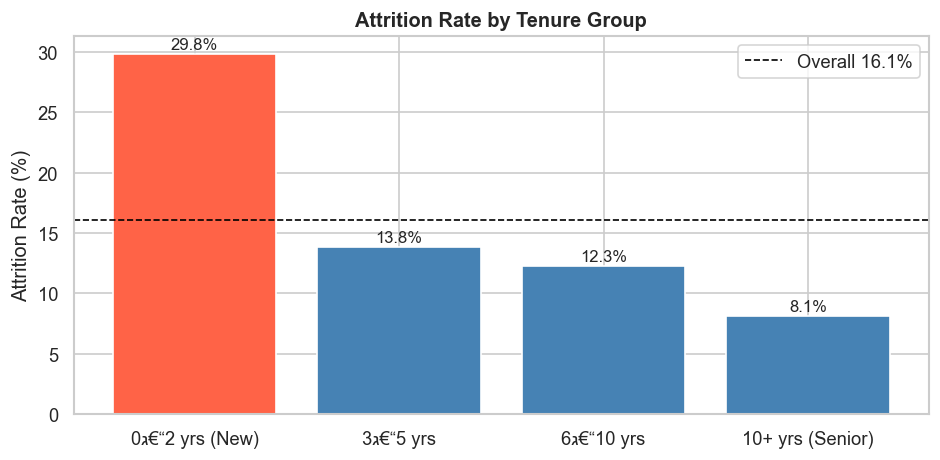

                  Total  Leavers  Attrition Rate %
Tenure_Group                                      
0–2 yrs (New)     342      102              29.8
3–5 yrs           434       60              13.8
6–10 yrs          448       55              12.3
10+ yrs (Senior)    246       20               8.1


In [17]:
# --- By Tenure (YearsAtCompany) — bins into new/mid/senior cohorts ---
df['Tenure_Group'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 99],
    labels=['0–2 yrs (New)', '3–5 yrs', '6–10 yrs', '10+ yrs (Senior)']
)

tenure_attr = (
    df.groupby('Tenure_Group', observed=True)['Attrition_Flag']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'Attrition Rate', 'sum': 'Leavers', 'count': 'Total'})
)
tenure_attr['Attrition Rate %'] = (tenure_attr['Attrition Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tenure_attr.index.astype(str), tenure_attr['Attrition Rate'] * 100,
              color=['tomato' if v > overall_rate else 'steelblue'
                     for v in tenure_attr['Attrition Rate']])
ax.axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1,
           label=f'Overall {overall_rate:.1%}')
ax.set_title('Attrition Rate by Tenure Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(tenure_attr[['Total', 'Leavers', 'Attrition Rate %']].to_string())

In [18]:
# Overtime is one of the strongest single predictors — show it clearly
ot_attr = (
    df.groupby('OverTime')['Attrition_Flag']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'Attrition Rate', 'sum': 'Leavers', 'count': 'Total'})
)
ot_attr['Attrition Rate %'] = (ot_attr['Attrition Rate'] * 100).round(1)
print("Attrition by OverTime status:")
print(ot_attr[['Total', 'Leavers', 'Attrition Rate %']].to_string())

Attrition by OverTime status:
          Total  Leavers  Attrition Rate %
OverTime                                  
No         1054      110              10.4
Yes         416      127              30.5


**KPI 1 Findings:**
- The overall attrition rate is approximately **16%** (237 of 1,470), elevated relative to typical industry benchmarks.
- **Sales** has the highest departmental attrition (**20.6%**). **HR** is second-highest (**19.0%**, but on a small base of just **63 employees / 12 leavers** — directional); **R&D** is lowest (**13.8%**) — though R&D is by far the largest department, so it still accounts for the most leavers in absolute terms.
- Among job roles, **Sales Representatives** stand out sharply at **39.8%** (N = 83) — roughly 2.5x the overall rate — followed by **Laboratory Technicians** (23.9%, N = 259) and the **Human Resources** role (23.1%, but only **N = 52 / 12 leavers**, so directional).
- **New hires (0-2 years)** have markedly higher attrition — a classic onboarding risk window.
- Employees working **OverTime** leave at **nearly triple** the rate of those who don't (**30.5% vs 10.4%**).

*Limitation: We don't know the voluntary vs. involuntary split of departures. Subgroups under ~100 employees (e.g. the HR department at 63 and the HR role at 52) carry wide statistical uncertainty — treat their rank order as suggestive, not precise.*

### KPI 1 (extension) — Department x Job Role: Where Risk Really Concentrates

**Why this cut?** Department averages hide a lot: "Sales" (20.6%) lumps together Sales Representatives and Sales Executives, who behave very differently. Crossing **Department x JobRole** shows which specific roles inside each department drive the risk, so interventions can target the right group rather than a whole department.

In [19]:
# --- Department x JobRole joint attrition (roles with >= 20 employees) ---
dept_role = (df.groupby(['Department', 'JobRole'])['Attrition_Flag']
             .agg(Rate='mean', N='count'))
dept_role['Rate %'] = (dept_role['Rate'] * 100).round(1)
dept_role = dept_role[dept_role['N'] >= 20].sort_values('Rate %', ascending=False)
print("Attrition rate by Department x JobRole (groups with N >= 20):")
print(dept_role[['N', 'Rate %']].to_string())

Attrition rate by Department x JobRole (groups with N >= 20):
                                                    N  Rate %
Department             JobRole                               
Sales                  Sales Representative        83    39.8
Research & Development Laboratory Technician      259    23.9
Human Resources        Human Resources             52    23.1
Sales                  Sales Executive            326    17.5
Research & Development Research Scientist         292    16.1
                       Healthcare Representative  131     6.9
                       Manufacturing Director     145     6.9
                       Manager                     54     5.6
Sales                  Manager                     37     5.4
Research & Development Research Director           80     2.5


**Department x Job-Role Findings:**
- Role risk varies enormously *within* a single department. Inside **Sales**, Sales Representatives leave at **39.8%** (N = 83) while Sales Executives leave at **17.5%** (N = 326) and Sales Managers at just **5.4%** (N = 37) — the "Sales = 20.6%" headline is an average across all three.
- The highest-risk role-in-department cells are **Sales / Sales Representative (39.8%, N = 83)**, **R&D / Laboratory Technician (23.9%, N = 259)**, and **HR / Human Resources (23.1%, N = 52)**.
- Managers are low-risk in both R&D (5.6%, N = 54) and Sales (5.4%, N = 37).

*Limitation: several role-in-department cells are small (Sales Rep N = 83, HR N = 52, Managers N = 37-54) — treat exact rates as directional. Groups under 20 were dropped to avoid noise.*

<a id='kpi2'></a>
## KPI 2 — Compensation & Retention

**Why this KPI?** Compensation is one of the most commonly cited drivers of turnover. We compare monthly income, salary hikes, and stock option levels between leavers and stayers.

**Note on rates:** `HourlyRate`, `DailyRate`, and `MonthlyRate` in this dataset are random-looking values that do *not* reconcile with `MonthlyIncome`. We use **`MonthlyIncome`** as the sole compensation measure.

In [20]:
comp_summary = df.groupby('Attrition')[['MonthlyIncome', 'PercentSalaryHike', 'StockOptionLevel']].mean().round(2)
comp_summary.index.name = 'Attrition'
print("Average compensation metrics by Attrition status:")
print(comp_summary.to_string())

Average compensation metrics by Attrition status:
           MonthlyIncome  PercentSalaryHike  StockOptionLevel
Attrition                                                    
No               6832.74              15.23              0.85
Yes              4787.09              15.10              0.53


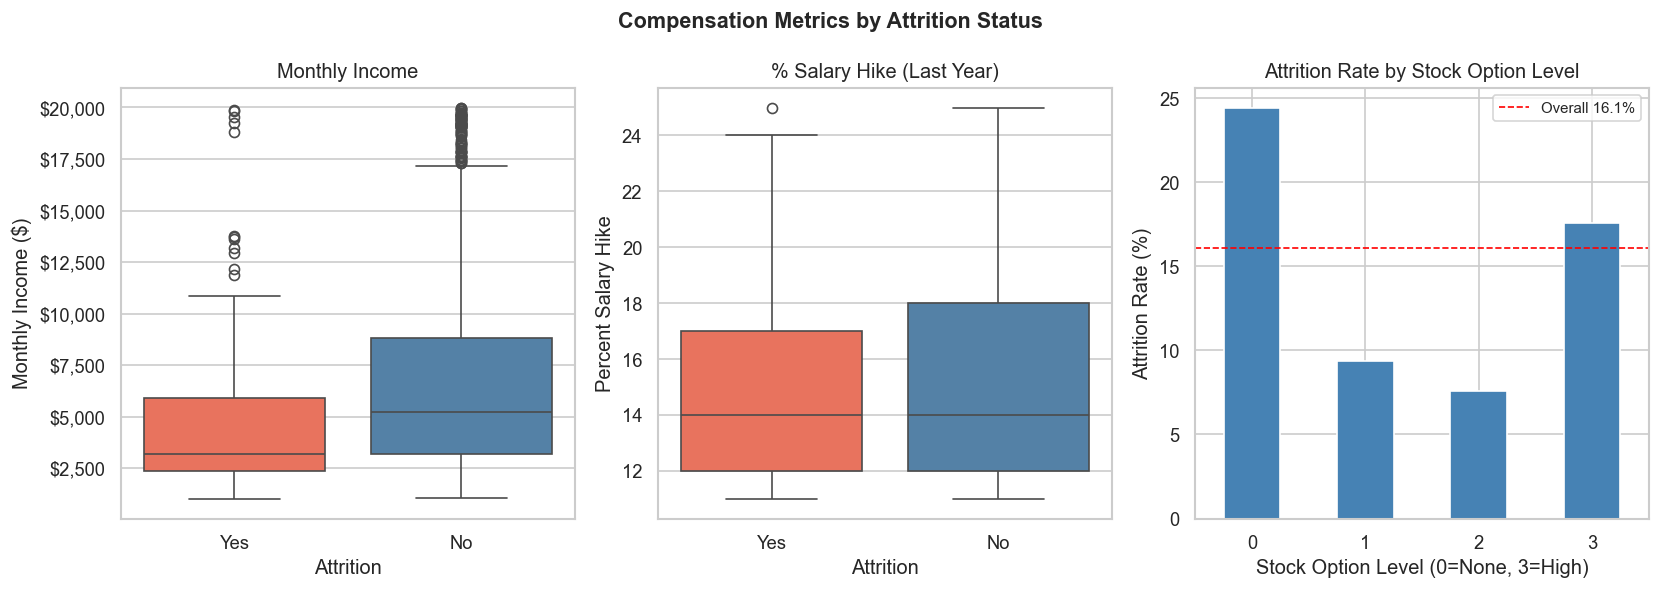

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Compensation Metrics by Attrition Status', fontsize=13, fontweight='bold')

palette = {'No': 'steelblue', 'Yes': 'tomato'}

# Monthly Income distribution
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=palette, ax=axes[0])
axes[0].set_title('Monthly Income')
axes[0].set_ylabel('Monthly Income ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Percent Salary Hike
sns.boxplot(data=df, x='Attrition', y='PercentSalaryHike', palette=palette, ax=axes[1])
axes[1].set_title('% Salary Hike (Last Year)')
axes[1].set_ylabel('Percent Salary Hike')

# Stock Option Level (discrete — bar chart more appropriate)
stock_attr = df.groupby(['StockOptionLevel', 'Attrition']).size().unstack(fill_value=0)
stock_rate = (stock_attr['Yes'] / stock_attr.sum(axis=1) * 100).round(1)
stock_rate.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].axhline(overall_rate * 100, color='red', linestyle='--', linewidth=1,
                label=f'Overall {overall_rate:.1%}')
axes[2].set_title('Attrition Rate by Stock Option Level')
axes[2].set_ylabel('Attrition Rate (%)')
axes[2].set_xlabel('Stock Option Level (0=None, 3=High)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

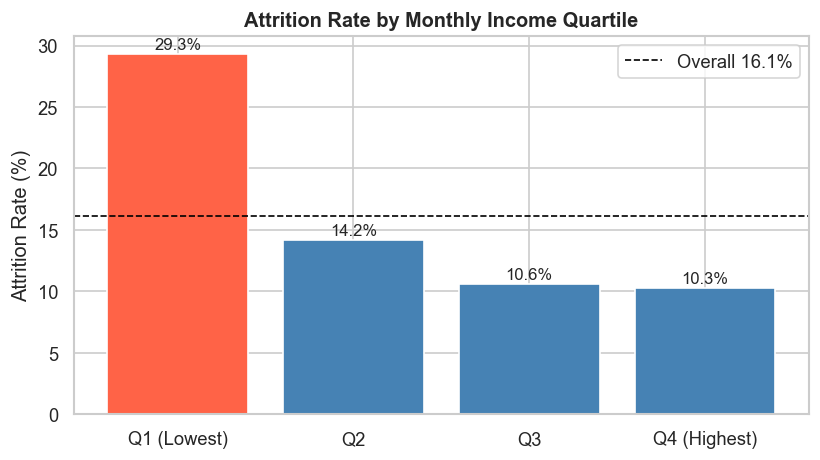

Income_Band
Q1 (Lowest)     29.3
Q2              14.2
Q3              10.6
Q4 (Highest)    10.3


In [22]:
# Income band analysis — does attrition concentrate in lower earners?
df['Income_Band'] = pd.qcut(df['MonthlyIncome'], q=4,
                            labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
income_attr = (
    df.groupby('Income_Band', observed=True)['Attrition_Flag']
    .mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(income_attr.index.astype(str), income_attr.values,
              color=['tomato' if v > overall_rate * 100 else 'steelblue'
                     for v in income_attr.values])
ax.axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1,
           label=f'Overall {overall_rate:.1%}')
ax.set_title('Attrition Rate by Monthly Income Quartile', fontsize=12, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(income_attr.to_string())

**KPI 2 Findings:**
- Employees who left earned on average **significantly less** than those who stayed.
- The lowest income quartile has the highest attrition rate — the gap is steep.
- **Stock option level 0** (no equity stake) associates with roughly double the attrition of level 1+.
- Percent salary hike shows minimal difference between leavers and stayers — hike size alone may not be the key lever; the absolute income level matters more.

*Limitation: Lower income often correlates with junior roles and shorter tenure. We cannot attribute attrition to pay alone without controlling for job level.*

### KPI 2 (extension) — Does Pay Buy Satisfaction? Income ֳ— Job Satisfaction

**Why this cut?** The compensation KPI showed that leavers earn less on average. But a crucial follow-up question for HR is whether **money and happiness actually move together**: if we raise pay, do we also raise job satisfaction (and therefore retention)? If pay and satisfaction turn out to be *independent*, then some unhappy leavers cannot be retained by money alone — a very different intervention.

We cross **MonthlyIncome** against the 1–4 **JobSatisfaction** scale, then zoom in on the leavers to see whether any are well-paid yet dissatisfied (a segment pay won't fix).

Mean MonthlyIncome by JobSatisfaction level (1=Low, 4=High):
JobSatisfaction
1    6562.0
2    6527.0
3    6480.0
4    6473.0

Correlation (JobSatisfaction vs MonthlyIncome): r = -0.007

Among LEAVERS only — MonthlyIncome by JobSatisfaction level:
                  N  Mean_Income  Median_Income
JobSatisfaction                                
1                66       4753.0         3260.0
2                46       4963.0         2812.0
3                73       4596.0         3441.0
4                52       4944.0         3167.0

Leavers with lowest JobSatisfaction (=1): N = 66
  ...of whom earning above the top-quartile threshold ($8,379): 12


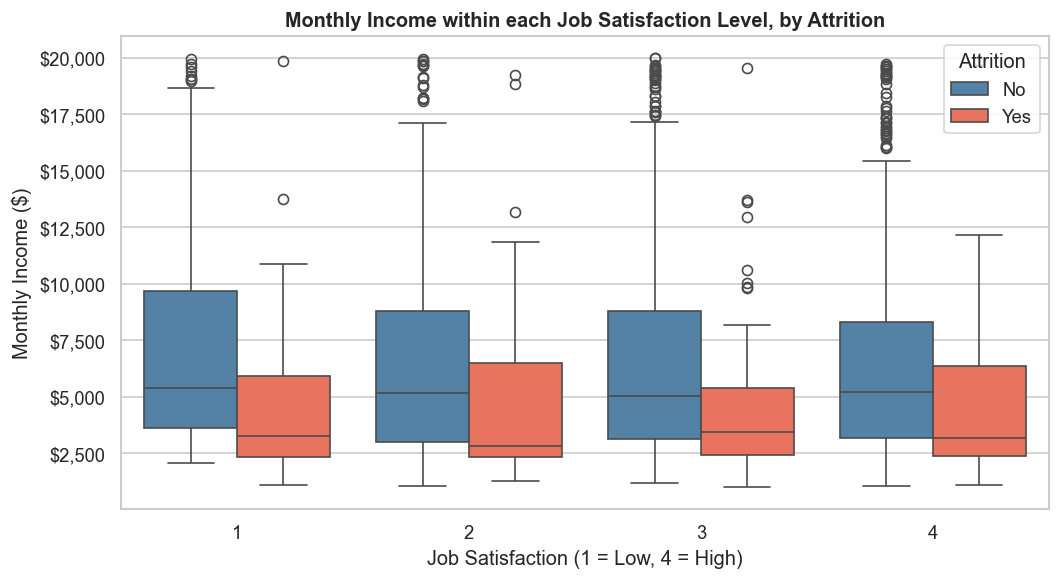

In [23]:
# --- Income vs Job Satisfaction: does higher pay buy higher satisfaction? ---
# Mean income at each satisfaction level across the whole workforce
inc_by_sat = df.groupby('JobSatisfaction')['MonthlyIncome'].mean().round(0)
corr_sat_inc = df['JobSatisfaction'].corr(df['MonthlyIncome'])
print("Mean MonthlyIncome by JobSatisfaction level (1=Low, 4=High):")
print(inc_by_sat.to_string())
print(f"\nCorrelation (JobSatisfaction vs MonthlyIncome): r = {corr_sat_inc:.3f}")

# Zoom in on leavers: income within each satisfaction level
leavers = df[df['Attrition'] == 'Yes']
print("\nAmong LEAVERS only — MonthlyIncome by JobSatisfaction level:")
print(
    leavers.groupby('JobSatisfaction')['MonthlyIncome']
    .agg(N='count', Mean_Income='mean', Median_Income='median')
    .round(0).to_string()
)

# Are any of the least-satisfied leavers actually well paid?
q75 = df['MonthlyIncome'].quantile(0.75)
js1_leavers = leavers[leavers['JobSatisfaction'] == 1]
well_paid_unhappy = int((js1_leavers['MonthlyIncome'] > q75).sum())
print(f"\nLeavers with lowest JobSatisfaction (=1): N = {len(js1_leavers)}")
print(f"  ...of whom earning above the top-quartile threshold (${q75:,.0f}): {well_paid_unhappy}")

# Box plot: income spread within each satisfaction level, split by attrition
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='JobSatisfaction', y='MonthlyIncome', hue='Attrition',
            palette={'No': 'steelblue', 'Yes': 'tomato'}, ax=ax)
ax.set_title('Monthly Income within each Job Satisfaction Level, by Attrition',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Job Satisfaction (1 = Low, 4 = High)')
ax.set_ylabel('Monthly Income ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

**Income vs. Job-Satisfaction Findings:**
- Pay and job satisfaction are **essentially unrelated** in this dataset: average monthly income is almost flat across all four satisfaction levels (\$6,562 at level 1 → \$6,473 at level 4), and the correlation is effectively zero (r = −0.007). Higher pay does **not** buy higher satisfaction here.
- This matters for retention strategy. Among the 237 leavers, the **66** who reported the *lowest* job satisfaction (score = 1) earned less on average (\$4,753) — but **12 of those 66 were nonetheless top-quartile earners** (above the \$8,379 income threshold). That small "**well-paid but unhappy**" group (N = 12) is a segment a pay rise is unlikely to retain; their issue looks like engagement, not compensation.
- Conversely, low-satisfaction leavers who are *also* low-paid may respond to a combination of pay and experience improvements — the two levers are not interchangeable.

*Limitation: satisfaction is self-reported, and the "well-paid but unhappy" group is small (N = 12) — treat it as a directional signal, not a precise estimate. Because pay and satisfaction are independent, neither can be read as causing the other.*

### KPI 2 (extension) — Income across Education Levels ֳ— Attrition

**Why this cut?** A common HR worry is the "over-qualified, under-paid" employee — someone with strong credentials who feels their pay doesn't match their qualifications and leaves. The `Education` field (1 = Below College … 5 = Doctor) lets us test this directly. We look at mean income at each education level split by attrition, check whether education is even a meaningful signal in this dataset, and probe specifically for a **highly-educated-but-low-paid** segment.

Mean MonthlyIncome by Education level and Attrition status:
Attrition            No     Yes
1 Below College  5926.0  4360.0
2 College        6586.0  4283.0
3 Bachelor       6883.0  4770.0
4 Master         7088.0  5335.0
5 Doctor         8560.0  5850.0

Attrition rate by Education level:
                   N  Rate %
1 Below College  170    18.2
2 College        282    15.6
3 Bachelor       572    17.3
4 Master         398    14.6
5 Doctor          48    10.4

Education vs JobLevel:     r = 0.102
Education vs MonthlyIncome: r = 0.095

Master/Doctor employees: N = 446, attrition = 14.1%
  ...of whom in the bottom income quartile (<= $2,911): N = 81, attrition = 24.7%


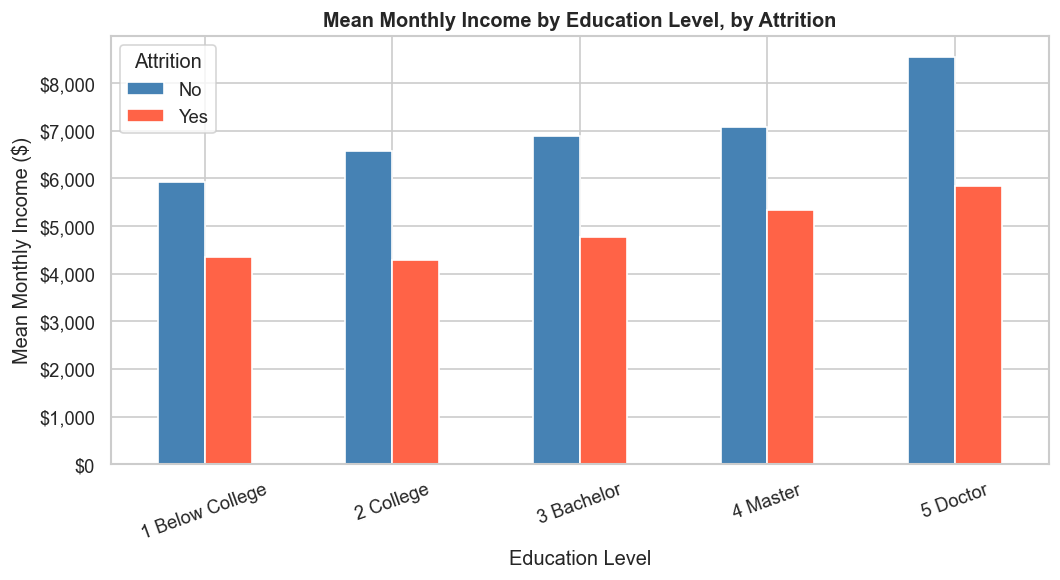

In [24]:
# --- Income across Education levels x Attrition status ---
edu_labels = {1: '1 Below College', 2: '2 College', 3: '3 Bachelor',
              4: '4 Master', 5: '5 Doctor'}

# Mean income by education level, split by attrition
inc_edu = (df.groupby(['Education', 'Attrition'])['MonthlyIncome']
           .mean().round(0).unstack('Attrition'))
inc_edu.index = [edu_labels[i] for i in inc_edu.index]
print("Mean MonthlyIncome by Education level and Attrition status:")
print(inc_edu.to_string())

# Attrition rate + N by education level
edu_rate = df.groupby('Education')['Attrition_Flag'].agg(N='count', Rate='mean')
edu_rate['Rate %'] = (edu_rate['Rate'] * 100).round(1)
edu_rate.index = [edu_labels[i] for i in edu_rate.index]
print("\nAttrition rate by Education level:")
print(edu_rate[['N', 'Rate %']].to_string())

# Is Education even a meaningful signal in this dataset?
print(f"\nEducation vs JobLevel:     r = {df['Education'].corr(df['JobLevel']):.3f}")
print(f"Education vs MonthlyIncome: r = {df['Education'].corr(df['MonthlyIncome']):.3f}")

# 'Credentialed but underpaid' probe: high education, bottom income quartile
q25 = df['MonthlyIncome'].quantile(0.25)
hi_edu = df[df['Education'] >= 4]                    # Master or Doctor
hi_edu_lowpay = hi_edu[hi_edu['MonthlyIncome'] <= q25]
print(f"\nMaster/Doctor employees: N = {len(hi_edu)}, "
      f"attrition = {hi_edu['Attrition_Flag'].mean() * 100:.1f}%")
print(f"  ...of whom in the bottom income quartile (<= ${q25:,.0f}): "
      f"N = {len(hi_edu_lowpay)}, attrition = {hi_edu_lowpay['Attrition_Flag'].mean() * 100:.1f}%")

# Grouped bar: mean income by education, leavers vs stayers
fig, ax = plt.subplots(figsize=(9, 5))
inc_edu.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Mean Monthly Income by Education Level, by Attrition',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Mean Monthly Income ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

**Income ֳ— Education Findings:**
- **Within every education level, leavers earn less than stayers** — the leaver-vs-stayer pay gap holds all the way from "Below College" up to "Doctor". This reinforces the overall KPI 2 pattern rather than overturning it.
- **Education is a weak signal in this dataset.** It correlates only weakly with job level (r = 0.10) and with income (r = 0.10), and attrition falls only gently as education rises (18.2% at "Below College" → 10.4% at "Doctor", though the Doctor group is small at N = 48). We should *not* lean on education as a strong explanatory variable here — consistent with the known weak education signal in IBM's synthetic data.
- **A "credentialed but underpaid" segment does stand out.** Master/Doctor holders overall leave at 14.1%, but those in the *bottom income quartile* (N = 81) leave at **24.7%** — well above the high-education baseline. This is the one actionable education-linked finding: highly-qualified employees paid at the bottom of the scale are a retention risk worth a targeted pay-equity review.

*Limitation: the "Doctor" group (N = 48) and the credentialed-underpaid segment (N = 81) are both small — treat their rates as directional, not precise. Education associations are weak overall, so avoid over-reading them.*

### KPI 2 (extension) — Testing the Confound: Income Gap *Within* Job Level

**Why this cut?** KPI 2 found leavers earn much less than stayers, but immediately flagged a confound: lower pay usually means a more junior job level, and junior levels leave more for many reasons beyond pay. Naming a confound isn't enough — we should *test* it. Here we compare leaver-vs-stayer income **within each job level**. If the gap shrinks or vanishes within levels, the raw gap was mostly a job-level artifact; if it persists, that is stronger evidence that pay itself matters. (This is a simple stratification, not a full regression — but it is enough to tell the two stories apart.)

Uncontrolled gap -> Stayers $6,833  vs  Leavers $4,787  (difference $2,046)

Within-JobLevel mean income (stayers vs leavers), the gap, and leaver counts:
Attrition       No      Yes  Gap ($)  Gap (% of stayer)  Leaver N
JobLevel                                                         
1           2854.0   2598.0    256.0                9.0       143
2           5474.0   5760.0   -285.0               -5.0        52
3           9891.0   9388.0    503.0                5.0        32
4          15620.0  13150.0   2470.0               16.0         5
5          19171.0  19464.0   -293.0               -2.0         5


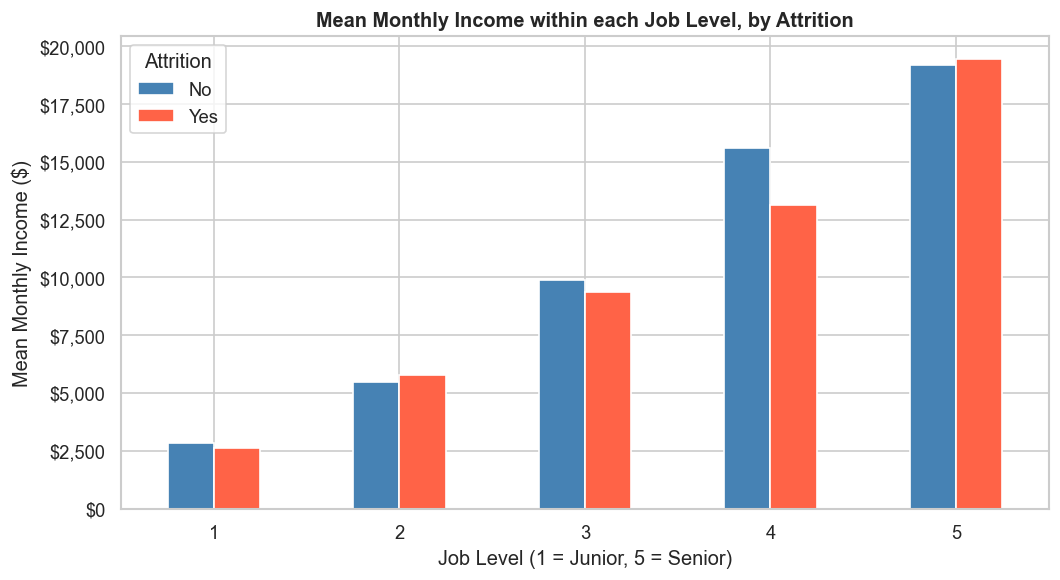

In [25]:
# --- Confound test: is the leaver/stayer income gap real, or a job-level artifact? ---
# Overall (uncontrolled) gap, for reference
overall_gap = df.groupby('Attrition')['MonthlyIncome'].mean()
print(f"Uncontrolled gap -> Stayers ${overall_gap['No']:,.0f}  vs  "
      f"Leavers ${overall_gap['Yes']:,.0f}  "
      f"(difference ${overall_gap['No'] - overall_gap['Yes']:,.0f})")

# Compare WITHIN each job level
within = df.groupby(['JobLevel', 'Attrition'])['MonthlyIncome'].mean().unstack('Attrition')
within['Gap ($)'] = (within['No'] - within['Yes']).round(0)
within['Gap (% of stayer)'] = ((within['No'] - within['Yes']) / within['No'] * 100).round(1)
within['Leaver N'] = df[df['Attrition'] == 'Yes'].groupby('JobLevel').size()
print("\nWithin-JobLevel mean income (stayers vs leavers), the gap, and leaver counts:")
print(within.round(0).to_string())

# Plot: mean income by job level, leavers vs stayers side by side
fig, ax = plt.subplots(figsize=(9, 5))
within[['No', 'Yes']].plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Mean Monthly Income within each Job Level, by Attrition',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Job Level (1 = Junior, 5 = Senior)')
ax.set_ylabel('Mean Monthly Income ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

**Income-within-Job-Level Findings (confound test):**
- The headline KPI 2 gap — stayers earn **\$6,833** vs leavers **\$4,787**, a **\$2,046** difference — **largely disappears once we compare people at the same job level.**
- Within **Job Level 1**: \$2,854 vs \$2,598 (gap ≈ \$256, 9%). Within **Level 2**: leavers actually earn *slightly more* (−\$285, −5%). Within **Level 3**: \$503 (5%). The large raw gap is therefore mostly an artifact of leavers being concentrated in lower, lower-paying job levels — **not** evidence that people are underpaid relative to their same-level peers.
- Levels 4 and 5 show larger or reversed gaps, but each has only **5 leavers** — far too few to interpret, so we disregard them.
- **Implication:** attrition is associated with being in a *lower job level*, not with within-band underpayment. This sharpens Recommendation 2 — the lever is career progression / levelling-up (and market-benchmarking the entry-level bands), not across-the-board raises for people already paid at market for their level.

*Limitation: this is a stratified comparison, not a full multivariate model — other confounders (tenure, role) still overlap with job level. Levels 4–5 are too small (N = 5 leavers each) to support any conclusion.*

<a id='kpi3'></a>
## KPI 3 — Work-Life Balance & Composite Satisfaction Index

**Why this KPI?** Beyond pay, employees leave when they're unhappy in their day-to-day experience. We look at the four satisfaction dimensions individually and then create a **Satisfaction Index** — the mean of all four — to see the composite picture.

All scores use a 1–4 scale (1 = Low, 4 = High).

In [26]:
# Composite Satisfaction Index
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance']

df['SatisfactionIndex'] = df[sat_cols].mean(axis=1)

sat_compare = df.groupby('Attrition')[sat_cols + ['SatisfactionIndex']].mean().round(3)
print("Mean satisfaction scores by Attrition status:")
print(sat_compare.to_string())

Mean satisfaction scores by Attrition status:
           JobSatisfaction  EnvironmentSatisfaction  RelationshipSatisfaction  WorkLifeBalance  SatisfactionIndex
Attrition                                                                                                        
No                   2.779                    2.771                     2.734            2.781              2.766
Yes                  2.468                    2.464                     2.599            2.658              2.547


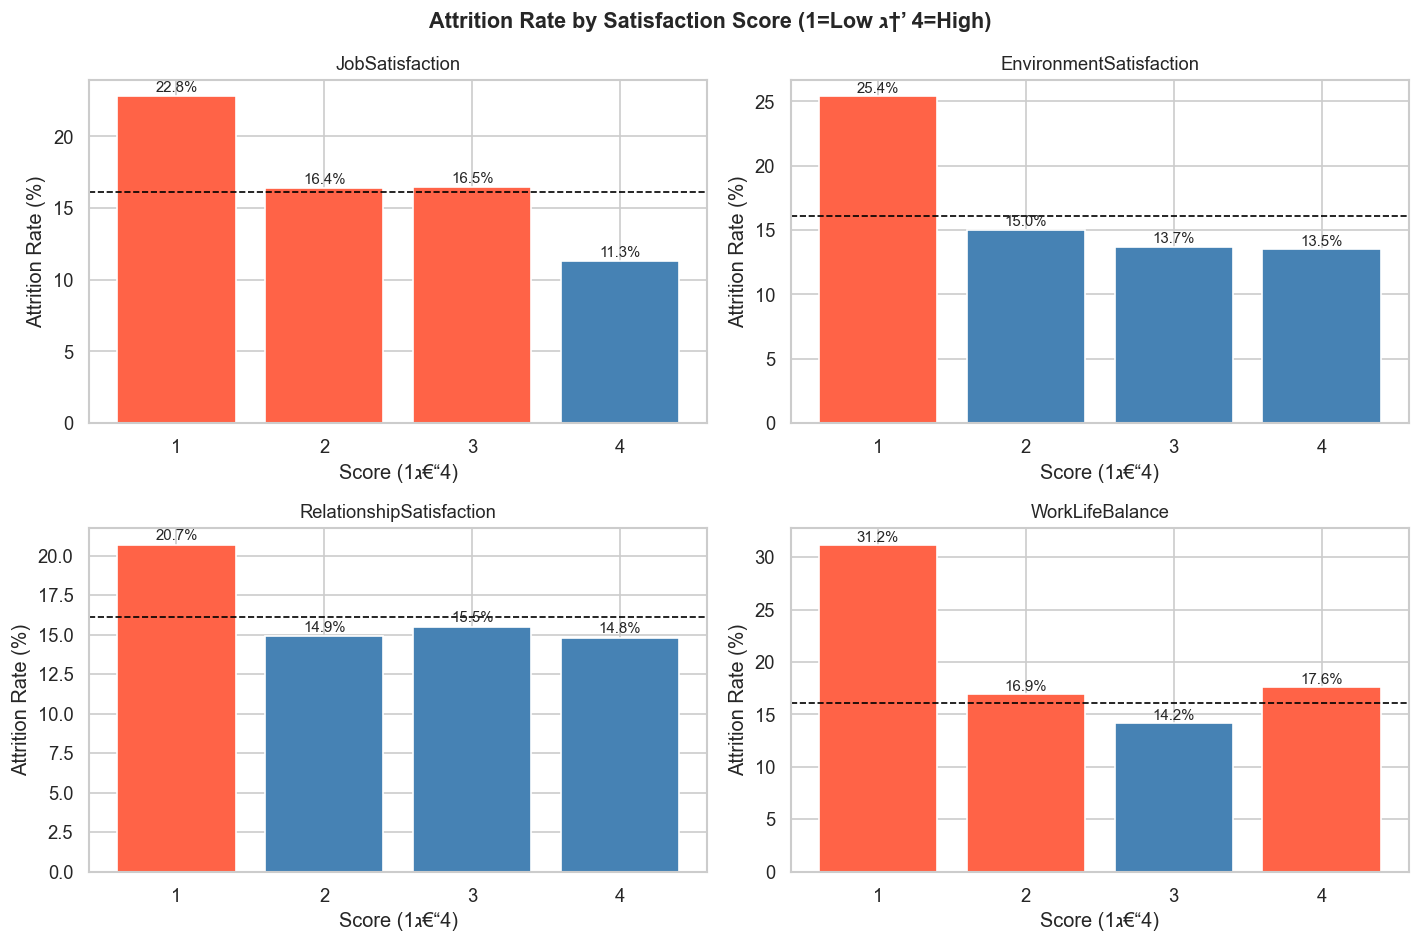

In [27]:
# Attrition rate by each satisfaction score level
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Attrition Rate by Satisfaction Score (1=Low → 4=High)', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), sat_cols):
    attr_by_score = (
        df.groupby(col)['Attrition_Flag'].mean() * 100
    ).round(1)
    bars = ax.bar(attr_by_score.index, attr_by_score.values,
                  color=['tomato' if v > overall_rate * 100 else 'steelblue'
                         for v in attr_by_score.values])
    ax.axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Score (1–4)')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xticks([1, 2, 3, 4])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

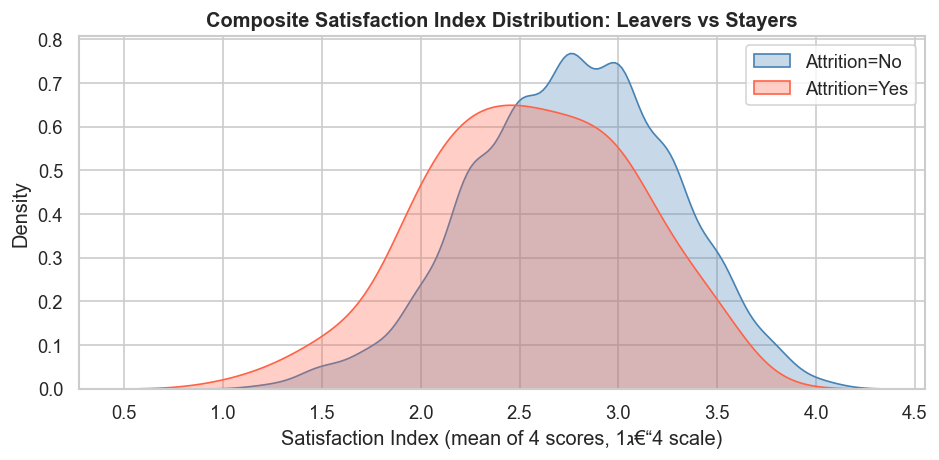

            count   mean    std   min   25%   50%  75%   max
Attrition                                                   
No         1233.0  2.766  0.493  1.25  2.50  2.75  3.0  4.00
Yes         237.0  2.547  0.531  1.00  2.25  2.50  3.0  3.75


In [28]:
# Distribution of the Satisfaction Index for leavers vs stayers
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in df.groupby('Attrition'):
    color = 'tomato' if label == 'Yes' else 'steelblue'
    sns.kdeplot(group['SatisfactionIndex'], ax=ax, label=f'Attrition={label}',
                fill=True, alpha=0.3, color=color)
ax.set_title('Composite Satisfaction Index Distribution: Leavers vs Stayers',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Satisfaction Index (mean of 4 scores, 1–4 scale)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')['SatisfactionIndex'].describe().round(3).to_string())

**KPI 3 Findings:**
- Leavers score lower on *every* satisfaction dimension than stayers, most notably on **JobSatisfaction** and **WorkLifeBalance**.
- The **Satisfaction Index** distribution for leavers is shifted left (lower) — employees who leave tend to have a pervasively less positive day-to-day experience, not just one bad dimension.
- Employees with a **WorkLifeBalance score of 1** (lowest) show the highest attrition rate.

*Limitation: Satisfaction scores are self-reported and may reflect personality traits as much as genuine workplace conditions. The direction of causality is also ambiguous — did low satisfaction cause departure, or did employees planning to leave rate things more negatively?*

### KPI 3 (extension) — Does Better Work-Life Balance Mean a *Longer* Stay?

**Why this cut?** KPI 3 showed lower work-life balance goes with a higher chance of leaving. But the guiding question also asks about *duration* — do people with worse balance leave **sooner**? We check average tenure-at-exit (YearsAtCompany among leavers) at each WorkLifeBalance score.

In [29]:
# --- Work-Life Balance vs tenure-at-exit (leavers only) ---
wlb_exit = (df[df['Attrition'] == 'Yes'].groupby('WorkLifeBalance')['YearsAtCompany']
            .agg(N='count', Mean_Tenure='mean').round(2))
print("Among LEAVERS - mean YearsAtCompany (tenure at exit) by WorkLifeBalance:")
print(wlb_exit.to_string())

Among LEAVERS - mean YearsAtCompany (tenure at exit) by WorkLifeBalance:
                   N  Mean_Tenure
WorkLifeBalance                  
1                 25         5.24
2                 58         5.33
3                127         5.18
4                 27         4.37


**Work-Life Balance vs. Tenure-at-Exit Findings:**
- Among leavers, tenure at exit is **basically flat** across balance scores 1-3 (~5.2-5.3 years) and only dips at score 4 (4.37 years, N = 27). So worse balance is associated with *whether* people leave (KPI 3) more than with *when* — the data does **not** show low-balance employees leaving markedly sooner.
- The lowest-balance leavers (score 1) are few (N = 25), so their average is directional only.

*Limitation: this looks only at employees who left; it says nothing about how balance affects the timing of those who stayed. Tenure at exit is also shaped by role and level, not balance alone.*

<a id='kpi4'></a>
## KPI 4 — Career Progression & Tenure

**Why this KPI?** Employees who feel stuck — no promotions, no role growth — are more likely to seek opportunities elsewhere. We examine years since last promotion, job level, and time in current role.

In [30]:
career_cols = ['YearsSinceLastPromotion', 'YearsInCurrentRole',
               'YearsAtCompany', 'JobLevel']

career_compare = df.groupby('Attrition')[career_cols].mean().round(2)
print("Career progression metrics by Attrition status:")
print(career_compare.to_string())

Career progression metrics by Attrition status:
           YearsSinceLastPromotion  YearsInCurrentRole  YearsAtCompany  JobLevel
Attrition                                                                       
No                            2.23                4.48            7.37      2.15
Yes                           1.95                2.90            5.13      1.64


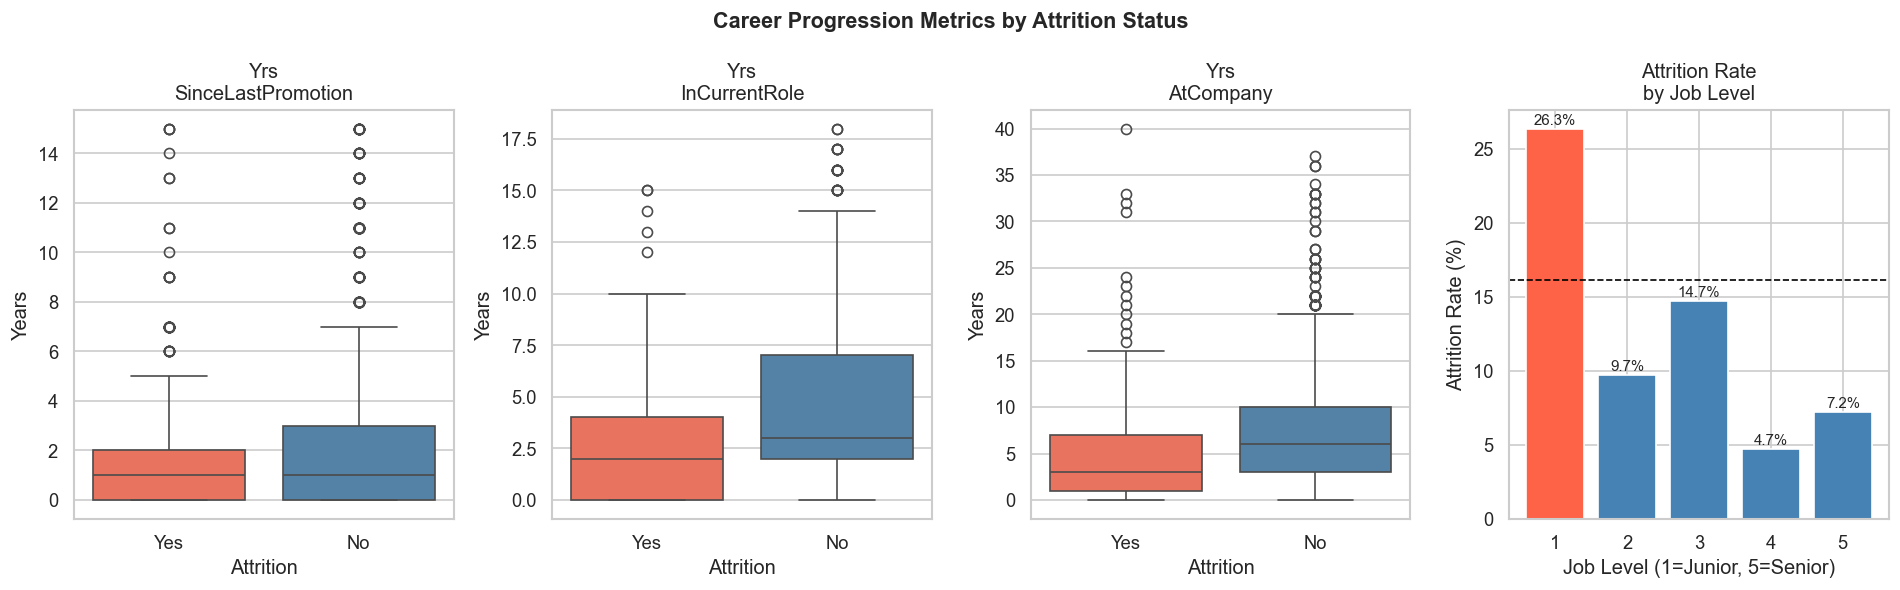

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Career Progression Metrics by Attrition Status', fontsize=13, fontweight='bold')

palette = {'No': 'steelblue', 'Yes': 'tomato'}

for ax, col in zip(axes, career_cols):
    if col == 'JobLevel':
        # Job level is discrete — bar chart of attrition rate per level
        jl_rate = (df.groupby('JobLevel')['Attrition_Flag'].mean() * 100).round(1)
        bars = ax.bar(jl_rate.index, jl_rate.values,
                      color=['tomato' if v > overall_rate * 100 else 'steelblue'
                             for v in jl_rate.values])
        ax.axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1)
        ax.set_title('Attrition Rate\nby Job Level')
        ax.set_xlabel('Job Level (1=Junior, 5=Senior)')
        ax.set_ylabel('Attrition Rate (%)')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    else:
        sns.boxplot(data=df, x='Attrition', y=col, palette=palette, ax=ax)
        ax.set_title(col.replace('Years', 'Yrs\n'))
        ax.set_ylabel('Years')

plt.tight_layout()
plt.show()

**KPI 4 Findings:**
- **Junior employees (Job Level 1)** have dramatically higher attrition than senior levels (stayers average job level 2.15 vs 1.64 for leavers).
- Leavers have **fewer years at the company** on average (5.13 vs 7.37) — confirming the new-hire risk window from KPI 1.
- **`YearsSinceLastPromotion` runs *counter* to the naֳ¯ve "promotion-drought" story.** Stayers have actually gone *longer* since their last promotion (**2.23 years**) than leavers (**1.95 years**) — that is, employees who leave were, on average, promoted **more** recently, not less. The data does **not** support the idea that being overdue for a promotion drives attrition here. This fits KPI 1: many leavers depart early in their tenure, before enough time has passed to build up a long gap since their last promotion.
- `YearsInCurrentRole` is also lower for leavers (2.90 vs 4.48 years), but this largely reflects their **shorter overall tenure** rather than a distinct "stuck in role" effect — we should not over-read it as employees outgrowing their roles.

*Limitation: `YearsSinceLastPromotion` is mechanically bounded by tenure (you cannot have waited 5 years for a promotion if you have only been here 2), so the raw averages partly reflect the tenure difference noted above. Job level also correlates strongly with income, so level-vs-pay effects cannot be fully separated without a multivariate model.*

### KPI 4 (extension) — Job Level x Tenure: New Churn vs. "Stuck" Juniors

**Why this cut?** Job Level 1 has the highest attrition, and new hires (0-2 yrs) have the highest tenure-based attrition — but are these the *same* people or two different problems? Crossing **Job Level x Tenure** separates normal new-hire churn from long-tenured juniors who never advanced. The two need different fixes: better onboarding vs. career-pathing.

In [32]:
# --- Job Level x Tenure joint attrition (focus on Levels 1-2), with N ---
jl_tenure = (df.groupby(['JobLevel', 'Tenure_Group'], observed=True)['Attrition_Flag']
             .agg(Rate='mean', N='count'))
jl_tenure['Rate %'] = (jl_tenure['Rate'] * 100).round(1)
print("Attrition rate by Job Level x Tenure (Levels 1 and 2):")
print(jl_tenure.loc[[1, 2]][['N', 'Rate %']].to_string())

Attrition rate by Job Level x Tenure (Levels 1 and 2):
                             N  Rate %
JobLevel Tenure_Group                 
1        0–2 yrs (New)   215    36.7
         3–5 yrs         209    19.6
         6–10 yrs        102    21.6
         10+ yrs (Senior)   17     5.9
2        0–2 yrs (New)    80    20.0
         3–5 yrs         161     8.7
         6–10 yrs        223     8.5
         10+ yrs (Senior)   70     4.3


**Job Level x Tenure Findings:**
- Within **Job Level 1**, attrition is highest for brand-new hires (**36.7%** at 0-2 yrs, N = 215) — but it stays elevated for longer-tenured juniors too: **21.6%** at 6-10 yrs (N = 102). These 6-10-year employees still at Level 1 look like a distinct "**stuck junior**" group, separate from new-hire churn.
- Within **Job Level 2**, the pattern is milder: 20.0% at 0-2 yrs (N = 80) falling to ~8.5% thereafter.
- **Implication:** the new-hire spike (an onboarding problem) and the long-tenured-Level-1 risk (a career-pathing problem) are two different issues needing two different interventions — Recommendation 5 should distinguish them.

*Limitation: the Level 1 / 10+ yrs cell is tiny (N = 17), and Level 2 / 0-2 yrs (N = 80) and 10+ yrs (N = 70) are under 100 — treat those rates as directional.*

<a id='kpi5'></a>
## KPI 5 — Performance & Training

**Why this KPI?** High performers who leave are especially costly. Training investment may signal company commitment to employee growth. We also look at whether performance or training frequency differs between leavers and stayers.

**Caveat on PerformanceRating:** This column only takes values **3 or 4** in this dataset. All employees are either "Excellent" or "Outstanding" by the internal rating system. Analytical power is very limited — small rate differences should not be over-interpreted.

In [33]:
print("PerformanceRating value counts:")
print(df['PerformanceRating'].value_counts().sort_index().to_string())

perf_compare = df.groupby('Attrition')[['PerformanceRating', 'TrainingTimesLastYear']].mean().round(3)
print("\nAverage PerformanceRating and Training by Attrition:")
print(perf_compare.to_string())

PerformanceRating value counts:
PerformanceRating
3    1244
4     226

Average PerformanceRating and Training by Attrition:
           PerformanceRating  TrainingTimesLastYear
Attrition                                          
No                     3.153                  2.833
Yes                    3.156                  2.624


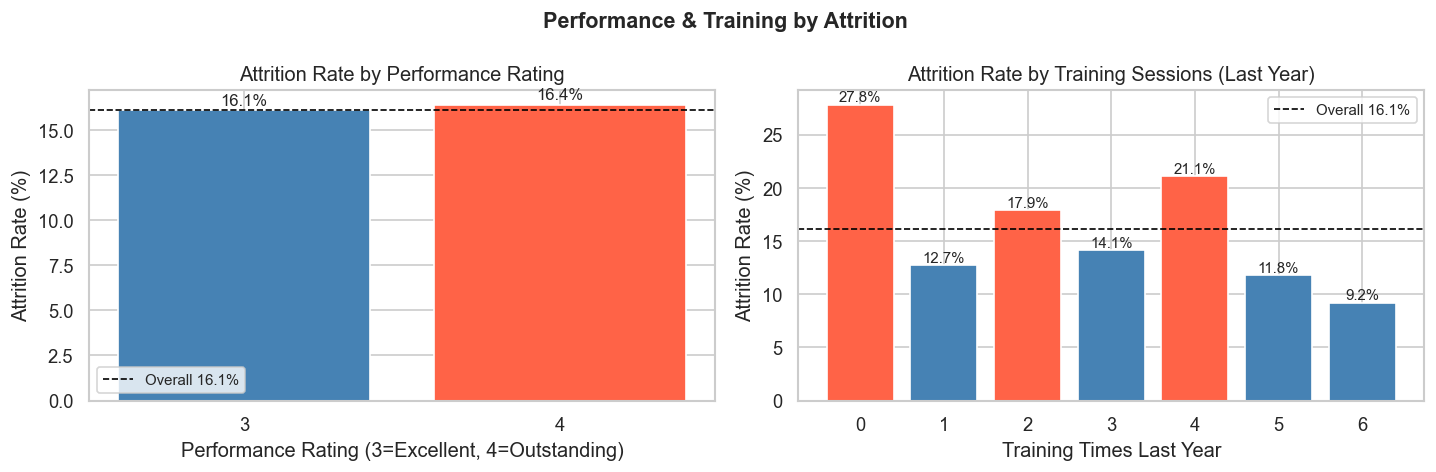

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Performance & Training by Attrition', fontsize=13, fontweight='bold')

# Attrition rate by PerformanceRating
perf_rate = (df.groupby('PerformanceRating')['Attrition_Flag'].mean() * 100).round(1)
bars = axes[0].bar(perf_rate.index, perf_rate.values,
                   color=['tomato' if v > overall_rate * 100 else 'steelblue'
                          for v in perf_rate.values])
axes[0].axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1,
                label=f'Overall {overall_rate:.1%}')
axes[0].set_title('Attrition Rate by Performance Rating')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('Performance Rating (3=Excellent, 4=Outstanding)')
axes[0].set_xticks([3, 4])
axes[0].legend(fontsize=9)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# Attrition rate by Training Times
train_rate = (df.groupby('TrainingTimesLastYear')['Attrition_Flag'].mean() * 100).round(1)
bars2 = axes[1].bar(train_rate.index, train_rate.values,
                    color=['tomato' if v > overall_rate * 100 else 'steelblue'
                           for v in train_rate.values])
axes[1].axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1,
                label=f'Overall {overall_rate:.1%}')
axes[1].set_title('Attrition Rate by Training Sessions (Last Year)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xlabel('Training Times Last Year')
axes[1].legend(fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [35]:
# --- Training: show the COUNT behind each rate, and test the tenure confound ---
train_tbl = df.groupby('TrainingTimesLastYear')['Attrition_Flag'].agg(N='count', Rate='mean')
train_tbl['Rate %'] = (train_tbl['Rate'] * 100).round(1)
print("Attrition rate by TrainingTimesLastYear, with group sizes:")
print(train_tbl[['N', 'Rate %']].to_string())
print(f"\nCorrelation TrainingTimesLastYear vs YearsAtCompany: "
      f"r = {df['TrainingTimesLastYear'].corr(df['YearsAtCompany']):.3f}")

Attrition rate by TrainingTimesLastYear, with group sizes:
                         N  Rate %
TrainingTimesLastYear             
0                       54    27.8
1                       71    12.7
2                      547    17.9
3                      491    14.1
4                      123    21.1
5                      119    11.8
6                       65     9.2

Correlation TrainingTimesLastYear vs YearsAtCompany: r = 0.004


**KPI 5 Findings:**
- **PerformanceRating** shows negligible difference between leavers and stayers — expected when the field has only two values (3/4). We cannot draw meaningful conclusions from it.
- **Training frequency is only weakly and non-monotonically related to attrition.** The one clear signal is the **zero-training** group: 27.8% attrition (N = 54), well above the ~16% baseline. The rest is noisy (1 session 12.7% / N = 71; 2 sessions 17.9% / N = 547; 4 sessions 21.1% / N = 123). The **6-session** group is genuinely lower at 9.2% (N = 65) — worth watching, but on a small base, not something to bank on.
- Training frequency is **essentially uncorrelated with tenure** (r = 0.00), so the training-retention pattern is *not* merely re-detecting the tenure effect; but neither is it a strong standalone driver.

*Limitation: PerformanceRating is essentially uninformative (near-constant) — do not cite it. Training is a one-year snapshot and several groups are small (state N when citing). Direction of causality is ambiguous: employees already planning to leave may have disengaged from training beforehand, rather than lack of training causing departure.*

<a id='kpi6'></a>
## KPI 6 — Commute Distance & Interaction with Overtime

**Why this KPI?** `DistanceFromHome` is the only commuting proxy available (no office-location field exists). Long commutes add stress and time cost. When combined with mandatory overtime, the burden multiplies.

We also test the three-way interaction: distance ֳ— overtime ֳ— role, to find the most at-risk sub-group.

In [36]:
dist_compare = df.groupby('Attrition')['DistanceFromHome'].describe().round(2)
print("DistanceFromHome by Attrition:")
print(dist_compare.to_string())

DistanceFromHome by Attrition:
            count   mean   std  min  25%  50%   75%   max
Attrition                                                
No         1233.0   8.92  8.01  1.0  2.0  7.0  13.0  29.0
Yes         237.0  10.63  8.45  1.0  3.0  9.0  17.0  29.0


### KPI 6 (extension) — Commute Distance by Job Role ֳ— Attrition (standalone)

**Why this cut?** One of the guiding questions asks specifically for average distance from home broken down by **job role and attrition status** — on its own, not filtered to overtime workers. The three-way interaction table further below answers a related but narrower question (overtime workers only). Here we give the direct, unfiltered answer: within each role, did leavers commute farther than stayers?

Mean DistanceFromHome (miles) by Job Role and Attrition status:
Attrition                    No    Yes  Diff (Yes-No)  Leaver N
JobRole                                                        
Healthcare Representative  9.20  17.67           8.47         9
Human Resources            6.60  13.42           6.82        12
Sales Executive            9.03  12.65           3.62        57
Manager                    7.93  10.00           2.07         5
Research Scientist         8.87   9.77           0.90        47
Laboratory Technician      9.33   9.66           0.33        62
Manufacturing Director     9.53   8.80          -0.73        10
Sales Representative       9.00   8.15          -0.85        33
Research Director          8.47   7.00          -1.47         2


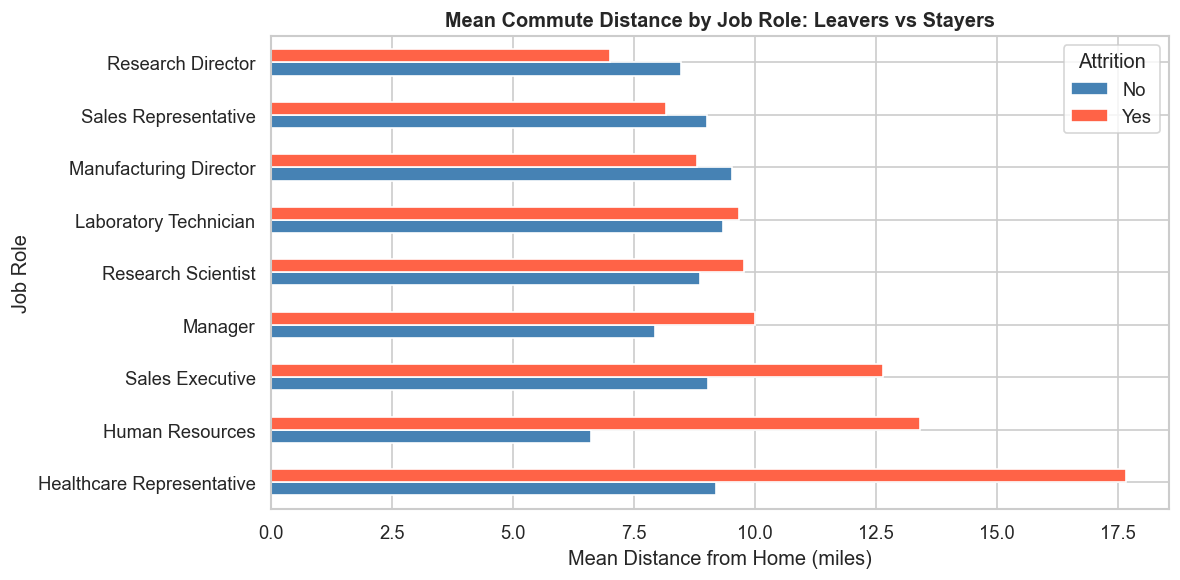

In [37]:
# --- Distance from home by Job Role x Attrition (standalone, NOT filtered by overtime) ---
# Directly answers the guiding question: within each role, do leavers commute farther?
dist_role = (df.groupby(['JobRole', 'Attrition'])['DistanceFromHome']
             .mean().unstack('Attrition').round(2))
dist_role['Diff (Yes-No)'] = (dist_role['Yes'] - dist_role['No']).round(2)
dist_role['Leaver N'] = df[df['Attrition'] == 'Yes'].groupby('JobRole').size()
dist_role = dist_role.sort_values('Diff (Yes-No)', ascending=False)
print("Mean DistanceFromHome (miles) by Job Role and Attrition status:")
print(dist_role.to_string())

# Plot leaver-vs-stayer mean distance per role
fig, ax = plt.subplots(figsize=(10, 5))
dist_role[['No', 'Yes']].plot(kind='barh', ax=ax, color=['steelblue', 'tomato'],
                              edgecolor='white')
ax.set_title('Mean Commute Distance by Job Role: Leavers vs Stayers',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Distance from Home (miles)')
ax.set_ylabel('Job Role')
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

**Distance ֳ— Job-Role ֳ— Attrition Findings:**
- Overall, leavers live slightly farther from work than stayers (10.6 vs 8.9 miles), but **the effect is very uneven across roles** — it is not a uniform commute story.
- The largest leaver-vs-stayer distance gaps are for **Healthcare Representatives** (17.7 vs 9.2 miles) and **Human Resources** (13.4 vs 6.6 miles) — but these rest on very few leavers (**N = 9** and **N = 12** respectively), so treat them as directional only.
- Among roles with more leavers, **Sales Executives** show the clearest signal: leavers averaged 12.7 miles vs 9.0 for stayers (N = 57).
- Notably, for **Sales Representatives** (N = 33) and **Laboratory Technicians** (N = 62) — the two highest-attrition roles overall — distance barely differs between leavers and stayers (it is even slightly *lower* for Sales Rep leavers). For these roles, commute is **not** the driver; their risk comes from overtime and role factors (see the interaction table below), not distance.

*Limitation: leaver counts per role are small (all under 100; several under 15), so role-level distance differences are directional, not precise. Distance is a proxy — no actual office location or remote-work status is known.*

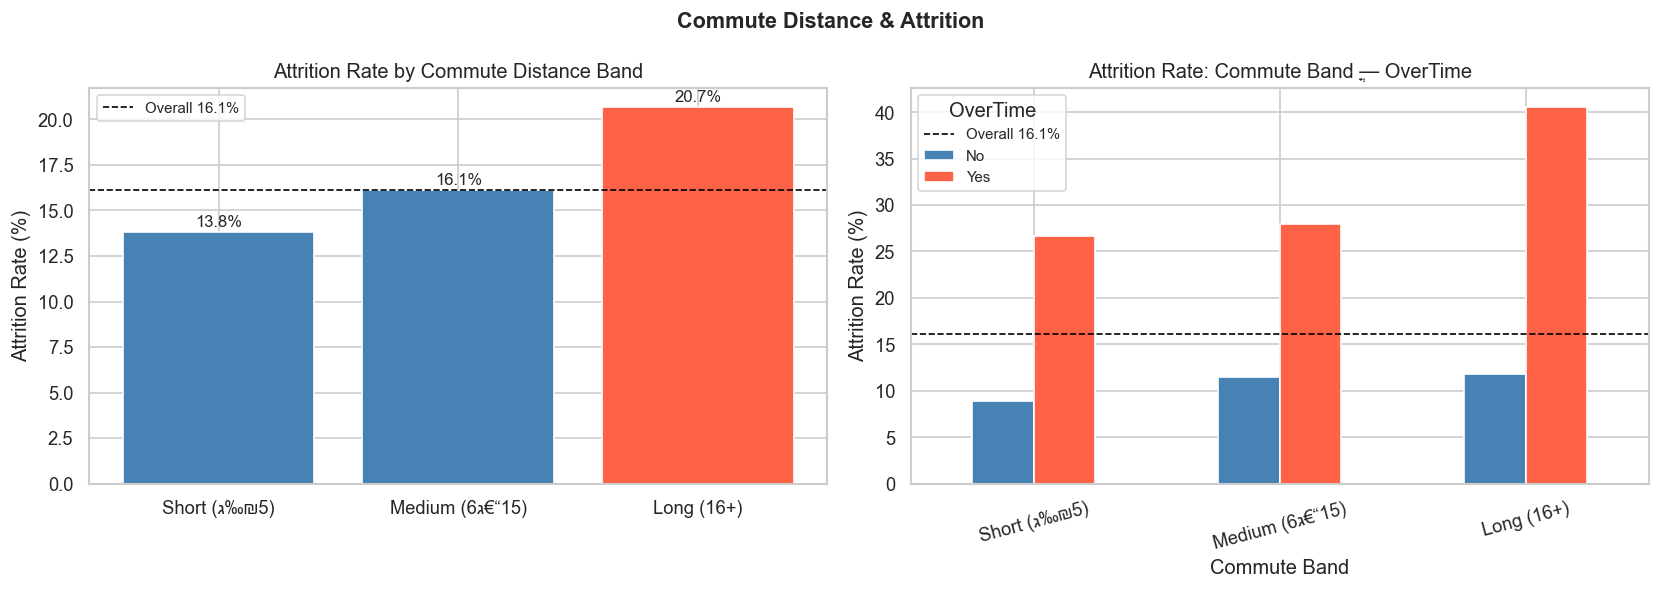

OverTime           No   Yes
Commute_Band               
Short (≤5)      8.9  26.7
Medium (6–15)  11.5  28.0
Long (16+)       11.8  40.6


In [38]:
# Bin distance into short / medium / long commute
df['Commute_Band'] = pd.cut(
    df['DistanceFromHome'],
    bins=[0, 5, 15, 100],
    labels=['Short (≤5)', 'Medium (6–15)', 'Long (16+)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Commute Distance & Attrition', fontsize=13, fontweight='bold')

# Attrition rate by commute band
commute_rate = (
    df.groupby('Commute_Band', observed=True)['Attrition_Flag'].mean() * 100
).round(1)
bars = axes[0].bar(commute_rate.index.astype(str), commute_rate.values,
                   color=['tomato' if v > overall_rate * 100 else 'steelblue'
                          for v in commute_rate.values])
axes[0].axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1,
                label=f'Overall {overall_rate:.1%}')
axes[0].set_title('Attrition Rate by Commute Distance Band')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].legend(fontsize=9)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# Interaction: commute ֳ— overtime
cross = (
    df.groupby(['Commute_Band', 'OverTime'], observed=True)['Attrition_Flag']
    .mean() * 100
).unstack('OverTime').round(1)
cross.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].axhline(overall_rate * 100, color='black', linestyle='--', linewidth=1,
                label=f'Overall {overall_rate:.1%}')
axes[1].set_title('Attrition Rate: Commute Band ֳ— OverTime')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xlabel('Commute Band')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='OverTime', fontsize=9)

plt.tight_layout()
plt.show()

print(cross.to_string())

In [39]:
# Three-way: distance ֳ— overtime ֳ— role — find the top at-risk combinations
at_risk = (
    df[df['OverTime'] == 'Yes']
    .groupby(['JobRole', 'Commute_Band'], observed=True)['Attrition_Flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Attrition Rate', 'count': 'N'})
    .query('N >= 10')  # only show groups with enough data
    .sort_values('Attrition Rate', ascending=False)
)
at_risk['Attrition Rate %'] = (at_risk['Attrition Rate'] * 100).round(1)
print("Top at-risk groups (OverTime=Yes, min 10 employees):")
print(at_risk[['N', 'Attrition Rate %']].head(10).to_string())

Top at-risk groups (OverTime=Yes, min 10 employees):
                                        N  Attrition Rate %
JobRole               Commute_Band                         
Sales Representative  Short (≤5)     12              66.7
Sales Executive       Long (16+)       22              59.1
Laboratory Technician Medium (6–15)  24              58.3
Research Scientist    Long (16+)       21              47.6
Laboratory Technician Short (≤5)     24              45.8
                      Long (16+)       14              42.9
Research Scientist    Short (≤5)     43              32.6
Sales Executive       Medium (6–15)  31              29.0
Research Scientist    Medium (6–15)  33              27.3
Sales Executive       Short (≤5)     41              22.0


**KPI 6 Findings:**
- Employees with **long commutes (16+ miles)** have higher attrition than those living close.
- The **interaction effect is substantial**: employees who both commute long distances *and* work overtime show the highest attrition rates — the two stressors compound.
- Among overtime workers, the most at-risk cells are small and therefore directional: **Sales Representative / short commute (66.7%, but N = 12 — only 8 people)**, **Sales Executive / long commute (59.1%, N = 22)**, and **Laboratory Technician / medium commute (58.3%, N = 24)**. The pattern (overtime + commute compounds risk in front-line roles) is consistent, but the exact percentages rest on 12-24 people each.

*Limitation: Distance is to a notional office — we don't know if remote/hybrid options exist, which would confound this. Every at-risk cell above has N under 25, so treat the rates as directional; validate with real commute data before acting.*

---

<a id='recs'></a>
## Retention Recommendations

Each recommendation is grounded in the KPI evidence above. Supporting data and limitations are stated explicitly.

> **Reminder:** All recommendations are hypotheses to test, derived from a synthetic cross-sectional dataset. Prioritise based on business context, feasibility, and piloting before broad rollout.

### 1. Strengthen New-Hire Onboarding and Early-Career Pathways
**Evidence:** Employees in their first 1–2 years have far higher attrition than any other tenure group (KPI 1).  
**Recommendation:** Invest in structured onboarding, buddy programmes, and 90-day check-ins. Pair new hires with mentors and provide a clear 12-month growth roadmap.  
**Limitation:** We don't know the *reason* for early departures (fit, compensation, expectations mismatch, or involuntary). Exit interview data would sharpen the diagnosis.

---

### 2. Review Compensation for Junior and Front-Line Roles
**Evidence:** The lowest income quartile has the highest attrition (KPI 2). Sales Representatives and Laboratory Technicians — both typically lower job-level roles — show elevated turnover (KPI 1).  
**Recommendation:** Conduct a market benchmarking exercise for Job Levels 1–2. Offer equity (stock options) to employees currently at level 0 — even a small grant correlates with substantially lower attrition.  
**Limitation:** Income correlates with job level and tenure, so raising pay alone may not solve the problem if role advancement opportunities are perceived as limited.

---

### 3. Audit and Cap Overtime for High-Risk Roles
**Evidence:** OverTime workers leave at roughly double the rate of non-overtime workers (KPI 1). The risk is compounded for long-distance commuters (KPI 6).  
**Recommendation:** Set overtime policies with explicit caps. Identify teams systematically relying on overtime and address root causes (understaffing, poor scope management). For long-commute overtime workers, explore remote/hybrid options.  
**Limitation:** Overtime may be voluntary in some cases. Causality is unclear — are stressed employees more likely to work overtime, or does overtime cause stress leading to departure?

---

### 4. Address Low Work-Life Balance and Job Satisfaction Proactively
**Evidence:** Employees with WorkLifeBalance=1 or JobSatisfaction=1 have the highest attrition rates (KPI 3). Leavers score lower on *all four* satisfaction dimensions — it is a pervasive experience gap, not a single dimension.  
**Recommendation:** Run regular pulse surveys (quarterly) to identify low-satisfaction pockets before employees decide to leave. Equip managers with tools to act on low scores. Consider flexible scheduling or autonomy increases for departments with low work-life scores.  
**Limitation:** Self-reported satisfaction surveys suffer from social desirability bias and may shift direction after a departure decision is already made.

---

### 5. Accelerate Career Progression for High-Potential Junior Employees
**Evidence:** Job Level 1 has by far the highest attrition (KPI 4). Employees with fewer years in their current role are more likely to leave — suggesting they may feel advancement is too slow.  
**Recommendation:** Create fast-track development tracks with defined promotion criteria. Offer stretch assignments and visible growth milestones at 6 and 12 months. Make promotion timelines transparent.  
**Limitation:** Without performance data of sufficient granularity, we cannot distinguish "high potential feeling stuck" from "underperformers leaving before being managed out."

---

### 6. Increase Training Access and Visibility of Learning Investment
**Evidence:** Employees with zero training sessions show slightly higher attrition (KPI 5). Perceived investment in employee growth is a known retention driver in HR literature.  
**Recommendation:** Ensure every employee has at least 2–3 formal training opportunities per year. Communicate the company's L&D investment to employees directly — perceived development opportunities matter as much as actual ones.  
**Limitation:** The training-attrition link in this dataset is weak (correlation is small). The benefit may come more from the signal of investment than the content of training itself.

---

<a id='summary'></a>
## Executive Summary for HR

*Written for a non-technical audience. No formulas or jargon.*

---

**The bottom line:** Based on an analysis of 1,470 employee records, roughly **1 in 6 employees** in this workforce left the company. That is an elevated rate, and it is not evenly spread — it concentrates in specific groups that are identifiable and, importantly, addressable.

**Where the problem is sharpest:**

1. **New employees** are the most vulnerable. Employees in their first two years leave at rates far above average. The first year is the critical retention window.

2. **Certain roles carry disproportionate risk.** Sales Representatives and Laboratory Technicians show significantly higher turnover. These are also among the lower-paying, more junior roles — compensation and career growth both likely play a role.

3. **Overtime is a strong warning sign.** Employees working overtime leave at nearly triple the rate of those who don't. When overtime is combined with a long commute, the risk is even higher. This suggests that work demands — not just pay — are a major pressure point.

4. **Pay and equity matter.** Employees earning in the bottom quarter of salaries leave at much higher rates. Employees with no stock options leave at double the rate of those with any equity stake. Feeling financially invested in the company's success appears to matter.

5. **Unhappy employees leave.** Leavers scored lower on job satisfaction, environment satisfaction, relationship satisfaction, and work-life balance — all four measures, consistently. No single factor stands out; it is a pervasively worse experience.

**What we recommend investigating first:**
- Redesign onboarding and set 90-day and 6-month check-in milestones.
- Benchmark pay for junior and front-line roles against the market; consider introducing basic stock options for all employees.
- Audit which teams systematically rely on overtime and address the root cause — usually understaffing or poor workload management.
- Launch a quarterly pulse survey to catch low satisfaction before it becomes a resignation letter.

**Important note:** This analysis is based on a synthetic dataset created for analytical training. The patterns are realistic but not drawn from a real organisation. Every recommendation should be treated as a hypothesis to pilot and test — not an instruction to act on immediately.

---
*Analysis completed: June 2026 | Dataset: IBM Synthetic HR (1,470 records) | Method: Exploratory data analysis and KPI benchmarking in Python (pandas, seaborn, matplotlib)*

---
## A Note on Statistical Rigor & Scope

- **Multiple comparisons:** across these KPIs we ran dozens of subgroup cuts. With that many comparisons, some apparent patterns are expected to arise by chance alone; findings that recur across independent cuts (e.g. new-hire risk appearing in *both* the tenure view and the job-level view) are more trustworthy than any single-cut result.
- **Variables left for future work:** `BusinessTravel`, `Gender`, and `MaritalStatus` are present in the data but were not analysed as segmenting variables in this pass — they are standard HR cuts worth exploring in a follow-up.